# 05 - Scheduler Evaluation

## Objective and Scope

This notebook represents the most critical analysis section of the thesis, summarizing the success of hardware scheduling algorithms. **All tree-based machine learning models (Random Forest, XGBoost, LightGBM)** and **deep learning models (CNN, LSTM, CNN-LSTM)**—carefully developed and trained in the preceding data preparation and modeling steps (Notebooks 01-04)—are tested here within a near-real-world cluster simulation environment. Adhering to professional MLOps practices, rather than being retrained from scratch, the models are directly loaded from previously serialized `.joblib` and `.pth` objects, rendering them immediately ready for live inference. Every artifact is checked against the source tree that produced it before anything is loaded: a model that no longer matches stops the run instead of quietly producing the scheduling chapter.

The comparison covers **28 policies** in five groups. The authoritative list is `POLICIES` in the simulation cell; this is what is in it:

**Group 1 — Non-learned heuristics (3 policies):**
* **FIFO (First-In-First-Out):** the industry-standard baseline, strict arrival order, no prioritisation of any kind. It is the reference every improvement figure is measured against, *not* a performance floor: a policy driven by a badly-ranking predictor can finish behind it, and in the 256-GPU run one does.
* **SRF (Smallest Resource First):** a rule-based heuristic that ignores runtime entirely and clears the smallest GPU demand first.
* **SJF-Oracle (Shortest-Job-First with perfect knowledge):** ranks on the *true* runtime. A perfect-information **reference policy** under this simulator's first-fit placement with head-of-line blocking, not an attainable optimum, and not a bound on the other policies (see the policy taxonomy below).

**Group 2 — Non-learned reference predictors (5 policies):**
* **SJF-UserMedian** and **SJF-ProfileMedian:** lookup tables built from the training partition alone, per user, and per five-column job profile, with a global-median fallback for unseen keys.
* **SJF-AlibabaEstimate (SJU / SJG / SJGG):** the trace's own precomputed per-user, per-group and per-group-per-GPU-type duration estimates. External reference points rather than held-out scores: the join that attaches them to test jobs is keyed partly on the target, so the results table marks them as label-keyed.

**Group 3 — Tree-based SJF-Pred policies (7 policies):**
* Random Forest, XGBoost and LightGBM on the numeric-only feature set (Experiment A), plus the one-hot and native-categorical variants that add high-cardinality nominal variables such as `user` and `gpu_type` (Experiment B).

**Group 4 — Feature ablation (1 policy):**
* **SJF-LightGBM (No Cluster-Load Features):** the native-categorical LightGBM refitted without the sweep-line cluster-load features, so "do those features matter?" can be answered at the scheduling-outcome level rather than only on MAE.

**Group 5 — Deep learning SJF-Pred policies (12 policies):**
* **Static DL (Experiments C & D):** 1D-CNN, LSTM and hybrid CNN-LSTM applied to single, disassociated rows, in numeric and one-hot variants.
* **Sequence DL (Experiments E & F):** the same three architectures over an explicit `seq_len = 10` sliding window of consecutive jobs, in numeric and one-hot variants.

A policy whose predictions turn out to carry no ordering at all, one value for every job, is **excluded before it is simulated** and reported as an excluded row, because such a policy is the no-prediction baseline wearing a model's name.

**Primary Objective:** To scientifically and statistically demonstrate the extent to which sequence-independent machine learning algorithms juxtaposed with temporal, sliding-window deep learning engines (CNN, LSTM, Hybrid) reduce system Wait Times and Turnaround Times compared with traditional heuristic policies, and, equally, where they do not.

## Literature and Real-World Architectures (Google Borg, Kubernetes, Apache YARN)

In massive data centers and High-Performance Computing (HPC) clusters, the **Job Scheduling** problem is the most critical algorithmic battle dictating the profitability of billion-dollar infrastructures. How are these systems managed in the real world?

*   **Google Borg & Kubernetes (K8s):** Google's internal *Borg* system, which has been in use for over a decade, and its open-source successor, *Kubernetes*, deploy container-based workloads. These systems know the CPU/RAM/GPU demands (requests/limits) up front, but **they do not know when the job will finish (runtime)**. Traditionally, they rely on static prioritization based on QoS (Quality of Service) classes.
*   **Apache YARN (Hadoop):** Used heavily in big data ecosystems, YARN relies on the *Capacity Scheduler* or the *Fair Scheduler*. Predictive capabilities are limited; it cannot proactively foresee a long-running Spark job.
*   **Slurm & PBS:** Dominant in supercomputing (HPC) and academic clusters, Slurm generally blends **Shortest Job First (SJF)** logic with **Backfilling** approaches. However, user-provided runtime estimates are notoriously inaccurate (users often maximize requests to prevent random job kills).

>
> 💡 **Industrial Value of this Thesis:** Instead of asking users or sysadmins **"How long will this job take?"**, the goal is to utilize Machine Learning (ML) and Deep Learning (DL) models as an **Oracle** to predict the completion time in milliseconds. This Predicted Runtime mathematically enables the cluster to schedule jobs much more aggressively and intelligently.

## Queueing Theory and Load Factor

At the heart of our simulation lies **Queueing Theory**. Specifically, our heterogeneous multi-server GPU cluster maps to complex literature variants far beyond simple M/M/c queues due to varying task requirements.

*   **Arrival Rate (λ):** The rate at which jobs flood the cluster. In the Alibaba trace, this is heavily bursty (non-Poisson).
*   **Service Rate (μ):** The speed at which GPUs chew through assigned jobs.
*   **Load Factor (ρ):** The aggregated stress placed upon the system. When the threshold $\rho \approx 1.0$ is breached, jobs risk waiting endlessly in the queue.

If our predictive models (XGBoost, LSTM, etc.) can accurately catapult short jobs to the absolute front of the queue (SJF priority), the overall **Wait Time** metric will dramatically collapse on a macroscopic scale.

## Discrete-Event Simulation (DES) Architecture

The simulation engine inside this notebook does not operate via a naive tick-based time counter. Instead, it utilizes an industry-standard **Discrete-Event Simulator (DES)**. The simulator quantum leaps through the time axis, triggering exclusively on `JOB_ARRIVAL` and `JOB_COMPLETION` events.

The following diagram maps out our purely engineered *Python Event Loop* and structurally depicts where the ML/DL Predictor intercepts the queue logic:

<p align="center">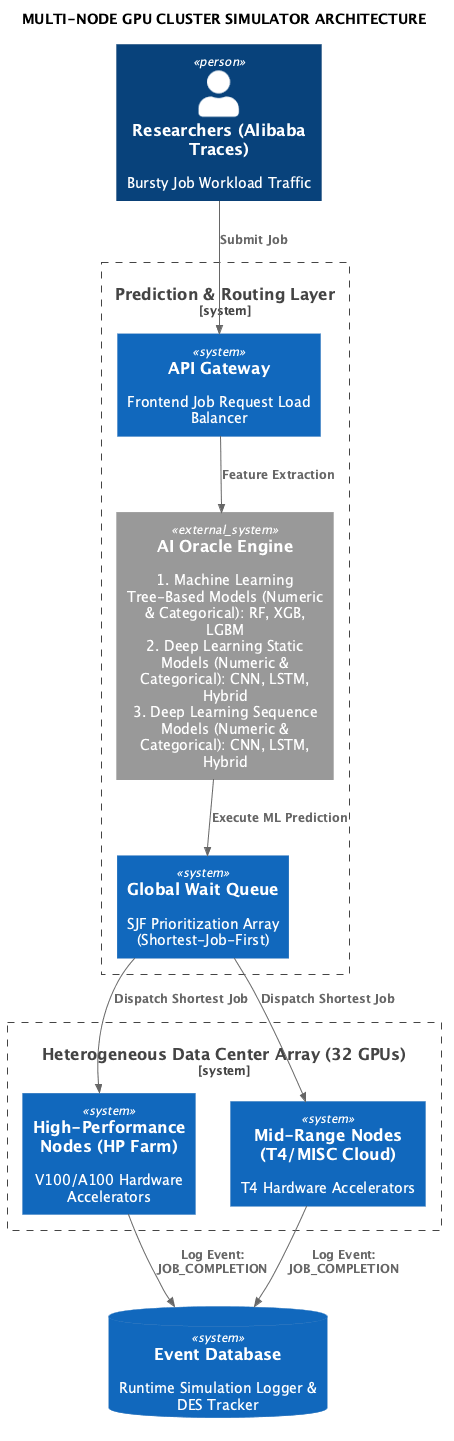</p>


## Integrating Sequence Models into the Simulation (Sliding Window)

Traditional tabular algorithms (Experiments A, B) and single-step deep learning baselines (Experiments C, D) ingest isolated rows to formulate predictions.

**Experiments E and F (Time-Series Sequence Models)** instead need a window of `seq_len = 10` consecutive jobs to produce one prediction, and no window may contain a job that arrives after the job being predicted.

>
> **How the windows are actually built:**
>
> The sequence predictions are computed **once, offline, before the simulator starts** — not inside the event loop. `predict_in_batches` (defined below) walks the test rows in the trace's own chronological order and, for row *i*, feeds the model the window `[i - 9 … i]`. The first nine test rows would otherwise have no history, so they are seeded with `history_prefix`: the last `seq_len - 1` rows of the **training** partition, scaled with the same scaler. No future row ever enters a window, and the earliest windows use genuine antecedent jobs rather than a padded repeat of the first test row.
>
> The resulting vector is attached to the job table as a static `predicted_runtime` column, exactly like a tree model's output, and the scheduler ranks on that column. There is no time-series buffer inside the simulator: neither module in `src/simulation/` imports `torch`, and no model is called while the event loop is running.

In [1]:
# ── 0. Environment & Path Setup ──────────────────────────────────────────────
import os
import sys
import warnings
from pathlib import Path

# ── CRITICAL: must be set BEFORE torch/xgboost/sklearn are imported ──────────
# PyTorch and XGBoost each load their own libiomp/libomp on macOS.
# Without KMP_DUPLICATE_LIB_OK the process gets a hard segfault (kernel crash).
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"           # single-thread OpenMP avoids conflict

# MPS / CUDA safety
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
os.environ["PYTORCH_NO_CUDA_MEMORY_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

warnings.filterwarnings("ignore")

# Anchor on a marker that only exists at the repository root, so the notebook
# works regardless of the directory the kernel was started from. parents[1]
# resolved one level short when the working directory was notebooks/.
def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    return start.parents[1]

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"[Setup] Project root : {PROJECT_ROOT}")
print(f"[Setup] Python path  : {sys.executable}")


[Setup] Project root : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling
[Setup] Python path  : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling/venv/bin/python


In [ ]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
# stdlib / third-party
import pandas as pd
import numpy as np
import joblib
import torch
import torch.nn as nn
from IPython.display import display
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "results" / "models"

from src.feature_engineering import prepare_features_for_model

from src.simulation.multi_node_simulator import MultiNodeClusterSimulator, provision_heterogeneous_gpu_cluster
# DegeneratePredictionError comes along with the schedulers because the policy
# loop below has to tell one specific refusal, a predictor that emits a single
# value for every job and so ranks nothing, apart from a wiring bug. That
# refusal is a reportable result about the model and must not abort the run.
from src.simulation.scheduler_simulator import (
    FIFOScheduler,
    SJFScheduler,
    SJFPredScheduler,
    SRFScheduler,
    DegeneratePredictionError,
)


# ── Shared p-value formatter ─────────────────────────────────────────────────
# A Wilcoxon or rank-correlation p on ~16k paired jobs underflows below 1e-300,
# and the default float repr prints those as "0.000000", a value no test can
# return. Rounding is worse: .round(4) maps a genuine 4.7e-08 onto the same 0.0
# as an underflow. Small p-values are shown as a bound, the rest at fixed
# precision. Defined here because the first table that needs it sits far above
# the significance cell.
def _fmt_p(v):
    return "< 1e-300" if v < 1e-300 else (f"{v:.2e}" if v < 1e-4 else f"{v:.4f}")


# CPU — must match OMP_NUM_THREADS=1 set above to keep OpenMP single-threaded
device = torch.device('cpu')
torch.set_num_threads(1)
print('PyTorch Device Setup:', device)
print('PyTorch version     :', torch.__version__)


# ── Figure style ─────────────────────────────────────────────────────────────
# This notebook set no style at all, so its figures came out at 100 dpi with
# text printing at 1.5-2.9 pt. The export script scrapes the inline PNG, so the
# inline dpi is what reaches the thesis.
import matplotlib.pyplot as _plt_style
import seaborn as _sns_style
_sns_style.set_theme(style="whitegrid", palette="muted")
_plt_style.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    # Same type scale as notebooks 01-04. These figures are authored on a
    # 14-18 in canvas and printed into a 6.10 in column, so type sized for the
    # authoring canvas lands below the ~6 pt legibility floor once reduced; the
    # canvas stays and the type is scaled instead. Ticks and legends sit one
    # step under notebook 04's 14 pt because the densest axes here list 28
    # policy names in one column, where every label pair collides at 14 pt.
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

## Load Serialized Models

The best models, completely finalized following hyperparameter optimization in the previous notebook (Notebook 04), were serialized to the `models/` directory in `.joblib` format. In this step, to entirely eliminate the cost of training time and simulate production performance, these models are loaded directly from disk into memory.

In [ ]:
import gc
import joblib
# model_artifact_is_current is the predicate notebook 04's save cells are gated
# on. Only the writer was gated, so this notebook loaded whatever .joblib or
# .pth happened to be on disk and a model fitted before a feature-engineering
# fix could still produce every scheduling figure the thesis prints. The reader
# is gated here too, so the two halves of the guarantee agree.
from src.tuning import model_artifact_is_current


def _reject_stale_artifacts(paths, context):
    """Stop the run on any artifact model_artifact_is_current rejects.

    Refuses rather than warns. Everything below -- every prediction, table,
    figure and significance test -- is downstream of these files, and nothing
    downstream can see which weights produced a prediction, so a warning here
    is a warning nobody can act on once the outputs exist.

    Each rejection carries WHY, because the three causes need different
    repairs: the file is absent, it has no provenance sidecar at all (it
    predates the check), or its sidecar no longer matches the source tree.
    """
    rejected = []
    for path in paths:
        path = Path(path)
        if model_artifact_is_current(path):
            continue
        if not path.exists():
            why = "file not found"
        elif not path.with_suffix(path.suffix + ".provenance.json").exists():
            why = "no provenance sidecar (predates the currency check)"
        else:
            why = "sidecar does not match the current source tree"
        rejected.append(f"    {path.name}: {why}")
    if rejected:
        print("=" * 78)
        print(f"  REFUSED — {len(rejected)} of {len(paths)} {context} artifacts are not current")
        print("=" * 78)
        raise RuntimeError(
            f"[STALE ARTIFACT] {len(rejected)} of {len(paths)} {context} artifacts are not "
            f"current, so this notebook will not simulate with them:\n"
            + "\n".join(rejected)
            + "\n  Re-run notebook 04 to refit them; its save cells call "
            "record_model_artifact, which writes the sidecar this check reads."
        )


# ── 2. Load tree-based models ─────────────────────────────────────────────────
print("[Step 1] Loading serialized models from disk...")

# Checked in one pass before the first load, so the refusal names every stale
# file rather than only the first one reached.
_REQUIRED_ARTIFACTS = [
    "rf_numeric.joblib", "xgb_numeric.joblib", "lgbm_numeric.joblib",
    "rf_categorical.joblib", "xgb_categorical.joblib",
    "lgbm_categorical_native.joblib", "xgb_categorical_native.joblib",
    "lstm_scaler_x.joblib", "lstm_scaler_y.joblib",
    "lstm_scaler_x_cat.joblib", "lstm_scaler_y_cat.joblib",
    "user_median_baseline.joblib", "profile_median_baseline.joblib",
    "cnn_numeric.pth", "lstm_numeric.pth", "cnn_lstm_numeric.pth",
    "cnn_categorical_pt.pth", "lstm_categorical_pt.pth", "cnn_lstm_categorical_pt.pth",
    "cnn_numeric_seq.pth", "lstm_numeric_seq.pth", "cnn_lstm_numeric_seq.pth",
    "cnn_categorical_seq.pth", "lstm_categorical_seq.pth", "cnn_lstm_categorical_seq.pth",
]
# These four are legitimately absent on some runs, so absence is not a refusal:
# the load guards below leave the object None and the simulation cell drops
# every policy whose object is None. A stale copy is still a refusal: an absent
# baseline is reported as absent, a stale one would be reported as a result.
_OPTIONAL_ARTIFACTS = [
    "alibaba_estimate_baseline.joblib",
    "alibaba_estimate_group_baseline.joblib",
    "alibaba_estimate_groupgpu_baseline.joblib",
    "lgbm_categorical_native_no_sweepline.joblib",
]
_reject_stale_artifacts(
    [MODEL_DIR / _n for _n in _REQUIRED_ARTIFACTS]
    + [MODEL_DIR / _n for _n in _OPTIONAL_ARTIFACTS if (MODEL_DIR / _n).exists()],
    "results/models",
)

# Numeric-only tree models
rf_num  = joblib.load(MODEL_DIR / "rf_numeric.joblib")
xgb_num = joblib.load(MODEL_DIR / "xgb_numeric.joblib")
lgb_num = joblib.load(MODEL_DIR / "lgbm_numeric.joblib")
gc.collect()

# Categorical tree models
rf_cat      = joblib.load(MODEL_DIR / "rf_categorical.joblib")
xgb_cat     = joblib.load(MODEL_DIR / "xgb_categorical.joblib")
lgb_cat_nat = joblib.load(MODEL_DIR / "lgbm_categorical_native.joblib")
gc.collect()

# DL scalers
lstm_scaler_x     = joblib.load(MODEL_DIR / "lstm_scaler_x.joblib")
lstm_scaler_y     = joblib.load(MODEL_DIR / "lstm_scaler_y.joblib")
lstm_scaler_x_cat = joblib.load(MODEL_DIR / "lstm_scaler_x_cat.joblib")
lstm_scaler_y_cat = joblib.load(MODEL_DIR / "lstm_scaler_y_cat.joblib")
gc.collect()

# Native-categorical XGBoost and the non-learned per-user median baseline.
# Both are new in Experiment B; the median "model" is just a lookup table.
xgb_cat_nat = joblib.load(MODEL_DIR / "xgb_categorical_native.joblib")
_user_median = joblib.load(MODEL_DIR / "user_median_baseline.joblib")
# ProfileMedian baseline: same idea as the per-user lookup above, but
# keyed on a 5-column profile (user, num_inst, num_cpu, gpu_demand,
# gpu_type) instead of user alone; see notebook 04.
_profile_median = joblib.load(MODEL_DIR / "profile_median_baseline.joblib")
# Alibaba's own pre-computed per-user duration estimate; absent
# when the auxiliary estimate file wasn't available for notebook 04.
_alibaba_estimate_path = MODEL_DIR / "alibaba_estimate_baseline.joblib"
_alibaba_estimate = joblib.load(_alibaba_estimate_path) if _alibaba_estimate_path.exists() else None
# SJG and SJGG, the trace's own per-group and per-group-per-GPU-type
# duration estimators (Weng et al. NSDI'22), same absent-if-unavailable guard.
_alibaba_estimate_group_path = MODEL_DIR / "alibaba_estimate_group_baseline.joblib"
_alibaba_estimate_group = joblib.load(_alibaba_estimate_group_path) if _alibaba_estimate_group_path.exists() else None
_alibaba_estimate_groupgpu_path = MODEL_DIR / "alibaba_estimate_groupgpu_baseline.joblib"
_alibaba_estimate_groupgpu = joblib.load(_alibaba_estimate_groupgpu_path) if _alibaba_estimate_groupgpu_path.exists() else None
# The ablated LGBM-Native model, without cluster_load_cpu, cluster_load_gpu
# or active_job_count, so whether the sweep-line feature group matters can be
# checked at the scheduling-outcome level rather than on MAE alone.
_lgb_no_sweepline_path = MODEL_DIR / "lgbm_categorical_native_no_sweepline.joblib"
lgb_cat_nat_no_sweepline = joblib.load(_lgb_no_sweepline_path) if _lgb_no_sweepline_path.exists() else None
gc.collect()

print("[Step 1] Tree models and scalers loaded.")

# ── 2.5 Load Deep Learning Model Weights (.pth) ────────────────────────────────
print("[Step 1.5] Loading DL models from disk (one group at a time)...")
from src.models.dl_runtime_predictor import RuntimePredictorCNN, RuntimePredictorLSTM, RuntimePredictorCNNLSTM

def _load(path):
    """Load a full PyTorch model object to CPU with no grad tracking."""
    m = torch.load(path, map_location="cpu", weights_only=False)
    m.eval()
    # Freeze all parameters to release autograd memory
    for p in m.parameters():
        p.requires_grad_(False)
    return m

try:
    # Group 1 — Static numeric (Exp C)
    cnn_static_num    = _load(MODEL_DIR / "cnn_numeric.pth")
    lstm_static_num   = _load(MODEL_DIR / "lstm_numeric.pth")
    hybrid_static_num = _load(MODEL_DIR / "cnn_lstm_numeric.pth")
    gc.collect()

    # Group 2 — Static categorical (Exp D)
    cnn_static_cat    = _load(MODEL_DIR / "cnn_categorical_pt.pth")
    lstm_static_cat   = _load(MODEL_DIR / "lstm_categorical_pt.pth")
    hybrid_static_cat = _load(MODEL_DIR / "cnn_lstm_categorical_pt.pth")
    gc.collect()

    # Group 3 — Sequence numeric (Exp E)
    cnn_model_num_seq    = _load(MODEL_DIR / "cnn_numeric_seq.pth")
    lstm_model_num_seq   = _load(MODEL_DIR / "lstm_numeric_seq.pth")
    hybrid_model_num_seq = _load(MODEL_DIR / "cnn_lstm_numeric_seq.pth")
    gc.collect()

    # Group 4 — Sequence categorical (Exp F)
    cnn_model_cat_seq    = _load(MODEL_DIR / "cnn_categorical_seq.pth")
    lstm_model_cat_seq   = _load(MODEL_DIR / "lstm_categorical_seq.pth")
    hybrid_model_cat_seq = _load(MODEL_DIR / "cnn_lstm_categorical_seq.pth")
    gc.collect()

    print("[SUCCESS] All 12 PyTorch models loaded and frozen on CPU!")
except Exception as e:
    # Re-raise rather than only printing: a model that fails to load leaves its
    # variable unbound and the next cell dies with an unrelated NameError.
    raise RuntimeError(f"DL model load failed: {e}") from e


## Load Data for Simulation

To maintain integrity and adhere to machine learning and deep learning ethics (preventing data leakage), the analysis must be performed strictly on the original `%20` test dataset, which the algorithms have never seen before.
To ensure this, the complete test sets (`X_test_num`, `X_test_cat_oh`, `X_test_cat_base`) are accurately reconstructed from the main sample using the `prepare_features_for_model` function and matched by their indices.

In [4]:
# ── 3. Load numeric-only test set ─────────────────────────────────────────────
print("[Step 2] Loading numeric-only test set...")
(job_df, X_train_num, X_test_num, _, y_test_num, _, _) = prepare_features_for_model(
    dataset="main", time_unit="s", test_size=0.20, random_state=42,
    feature_mode="numeric_only",
)
print(f"  X_test_num shape: {X_test_num.shape}")

[Step 2] Loading numeric-only test set...
  X_test_num shape: (16437, 9)


In [5]:
# ── 4. Load categorical (one-hot) test set ────────────────────────────────────
print("[Step 2] Loading categorical (one-hot) test set...")
(_, X_train_cat_oh, X_test_cat_oh, _, _, _, cat_cols_oh) = prepare_features_for_model(
    dataset="main", time_unit="s", test_size=0.20, random_state=42,
    feature_mode="with_categorical_onehot",
)
print(f"  X_test_cat_oh shape: {X_test_cat_oh.shape}")

[Step 2] Loading categorical (one-hot) test set...
  X_test_cat_oh shape: (16437, 591)


In [6]:
# ── 5. Load categorical (native) test set ─────────────────────────────────────
print("[Step 2] Loading categorical (native) test set...")
(_, _, X_test_cat_base, _, _, _, cat_cols_base) = prepare_features_for_model(
    dataset="main", time_unit="s", test_size=0.20, random_state=42,
    feature_mode="with_categorical",
)
for col in cat_cols_base:
    X_test_cat_base[col] = X_test_cat_base[col].astype("category")
print(f"  X_test_cat_base shape: {X_test_cat_base.shape}")

[Step 2] Loading categorical (native) test set...
  X_test_cat_base shape: (16437, 11)


## Generate Predictions

All loaded models (Numeric and Categorical versions) process their specific input structures drawn from the test split via a feed-forward inference pass, producing the runtime prediction data necessary for JCT calculations.

### 1. Machine Learning (Tree-based) Predictions (Experiments A & B)
Tree-based models operate on static, instantaneous tabular inputs.

In [7]:
# ── 6. Tree model predictions ────────────────────────────────────────────────
print("[Step 3] Generating tree model predictions...")

# Numeric-only
preds_rf_num  = rf_num.predict(X_test_num)
preds_xgb_num = xgb_num.predict(X_test_num)
preds_lgb_num = lgb_num.predict(X_test_num)

# Categorical
preds_rf_cat  = rf_cat.predict(X_test_cat_oh)
preds_xgb_cat = xgb_cat.predict(X_test_cat_oh)
preds_lgb_cat = lgb_cat_nat.predict(X_test_cat_base)

# Native-categorical XGBoost shares the LightGBM-native feature frame.
preds_xgb_cat_nat = xgb_cat_nat.predict(X_test_cat_base)
# The per-user median is a lookup, not an estimator: unseen users fall back to
# the global training median, exactly as in notebook 04.
preds_user_median = (
    job_df.loc[X_test_cat_base.index, "user"]
    .map(_user_median["table"]).fillna(_user_median["global"]).to_numpy()
)
# ProfileMedian is a 5-column groupby lookup, not a per-user map: merge on the
# same profile columns as notebook 04, falling back to the global median.
_profile_test_rows = job_df.loc[X_test_cat_base.index, _profile_median["cols"]]
preds_profile_median = (
    _profile_test_rows.merge(_profile_median["table"], on=_profile_median["cols"], how="left")
    ["profile_median"].fillna(_profile_median["global"]).to_numpy()
)
if _alibaba_estimate is not None:
    _ae_job_ids = job_df.loc[X_test_cat_base.index, "job_id"]
    preds_alibaba_estimate = (
        _ae_job_ids.map(_alibaba_estimate["lookup"]).fillna(_alibaba_estimate["global"]).to_numpy()
    )
if _alibaba_estimate_group is not None:
    _ae_job_ids = job_df.loc[X_test_cat_base.index, "job_id"]
    preds_alibaba_estimate_group = (
        _ae_job_ids.map(_alibaba_estimate_group["lookup"]).fillna(_alibaba_estimate_group["global"]).to_numpy()
    )
if _alibaba_estimate_groupgpu is not None:
    _ae_job_ids = job_df.loc[X_test_cat_base.index, "job_id"]
    preds_alibaba_estimate_groupgpu = (
        _ae_job_ids.map(_alibaba_estimate_groupgpu["lookup"]).fillna(_alibaba_estimate_groupgpu["global"]).to_numpy()
    )
if lgb_cat_nat_no_sweepline is not None:
    # Same feature frame as SJF-LightGBM (Native Categorical), minus the three
    # sweep-line columns the model was never fit on.
    _X_test_no_sweepline = X_test_cat_base.drop(
        columns=[c for c in ["cluster_load_cpu", "cluster_load_gpu", "active_job_count"] if c in X_test_cat_base.columns]
    )
    preds_lgb_cat_no_sweepline = lgb_cat_nat_no_sweepline.predict(_X_test_no_sweepline)
    preds_lgb_cat_no_sweepline = np.maximum(preds_lgb_cat_no_sweepline, 0)

print("[Step 3] All tree model predictions generated.")
# Clip to non-negative: a negative predicted runtime would let SJF-Pred treat
# that job as shortest and jump the queue, and would corrupt the Model MAE
# column. Notebook 04's own reported DL metrics are already computed on clipped
# predictions; this makes the simulation match.
for _name in [
    "preds_rf_num",
    "preds_xgb_num",
    "preds_lgb_num",
    "preds_rf_cat",
    "preds_xgb_cat",
    "preds_lgb_cat",
    "preds_xgb_cat_nat",
]:
    globals()[_name] = np.maximum(globals()[_name], 0)


# ── 6.5 Prepare PyTorch Tensors for Deep Learning ────────────────────────────
print("[Step 3.5] Scaling data and converting to PyTorch Tensors...")
X_test_num_scaled = lstm_scaler_x.transform(X_test_num)
X_test_cat_scaled = lstm_scaler_x_cat.transform(X_test_cat_oh)

# Real antecedent jobs for the first (SEQ_LEN - 1) test rows, so sequence models
# see genuine history instead of a padded repeat of themselves.
SEQ_LEN = 10
history_num_scaled = lstm_scaler_x.transform(X_train_num.iloc[-(SEQ_LEN - 1):])
history_cat_scaled = lstm_scaler_x_cat.transform(X_train_cat_oh.iloc[-(SEQ_LEN - 1):])

X_test_num_t_2d = torch.tensor(X_test_num_scaled, dtype=torch.float32).to(device)
X_test_cat_t_2d = torch.tensor(X_test_cat_scaled, dtype=torch.float32).to(device)
print(f"X_test_num_t_2d shape: {X_test_num_t_2d.shape}")
print(f"X_test_cat_t_2d shape: {X_test_cat_t_2d.shape}")


[Step 3] Generating tree model predictions...
[Step 3] All tree model predictions generated.
[Step 3.5] Scaling data and converting to PyTorch Tensors...
X_test_num_t_2d shape: torch.Size([16437, 9])
X_test_cat_t_2d shape: torch.Size([16437, 591])


In [8]:
# ── Batch Inference Engine for Memory Stability ───────────────────────────────
import gc

def predict_in_batches(model, x_tensor_2d, is_sequence=True, seq_len=10, batch_size=8192, history_prefix=None):
    """
    Predicts in small batches to prevent 10GB+ RAM exhaustion (Kernel Crashes).

    history_prefix : torch.Tensor, optional
        The last (seq_len - 1) SCALED rows immediately preceding x_tensor_2d
        (e.g. the tail of the training set). When given, the sliding window
        for the first few rows uses this real history instead of padding
        with a repeated copy of the first row.
    """
    model.eval()
    n_samples = x_tensor_2d.shape[0]
    all_preds = []

    if is_sequence and history_prefix is not None:
        extended = torch.cat([history_prefix.to(x_tensor_2d.device), x_tensor_2d], dim=0)
        offset = history_prefix.shape[0]
    else:
        extended = x_tensor_2d
        offset = 0

    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            if is_sequence:
                # Build 3D windows for THIS batch only
                batch_X = []
                for idx in range(i, end_idx):
                    end = offset + idx + 1
                    start = max(0, end - seq_len)
                    seq = extended[start:end]
                    pad_len = seq_len - seq.shape[0]
                    if pad_len > 0:
                        padding = seq[0].unsqueeze(0).repeat(pad_len, 1)
                        seq = torch.cat([padding, seq], dim=0)
                    batch_X.append(seq.unsqueeze(0))
                
                batch_X_tensor = torch.cat(batch_X, dim=0).to(device)
                preds = model(batch_X_tensor)
            else:
                # Static 2D -> 3D(CNN/LSTM static input format [N, 1, F])
                batch_X_tensor = x_tensor_2d[i:end_idx].unsqueeze(1).to(device)
                preds = model(batch_X_tensor)
            
            all_preds.append(preds.cpu().numpy().flatten())
            
            # Periodic memory cleanup
            if i % (batch_size * 5) == 0:
                gc.collect()
                if device.type == 'cuda': torch.cuda.empty_cache()
                
    return np.concatenate(all_preds)

print("[Setup] Batch Inference Engine Loaded.")


[Setup] Batch Inference Engine Loaded.


### 2. Static Deep Learning Predictions (Experiments C & D)
Classical PyTorch models (CNN, LSTM) generate predictions on instantaneous rows without using temporal sliding windows.

In [9]:

# ── Static DL (Experiment C & D) Predictions (Batched) ──
print("Generating static DL predictions in batches...")

X_test_num_t = torch.tensor(X_test_num_scaled, dtype=torch.float32)
X_test_cat_t = torch.tensor(X_test_cat_scaled, dtype=torch.float32)

# Numeric Track
preds_cnn_static_num = lstm_scaler_y.inverse_transform(predict_in_batches(cnn_static_num, X_test_num_t, is_sequence=False).reshape(-1, 1)).flatten()
preds_lstm_static_num = lstm_scaler_y.inverse_transform(predict_in_batches(lstm_static_num, X_test_num_t, is_sequence=False).reshape(-1, 1)).flatten()
preds_hybrid_static_num = lstm_scaler_y.inverse_transform(predict_in_batches(hybrid_static_num, X_test_num_t, is_sequence=False).reshape(-1, 1)).flatten()

# Categorical Track
preds_cnn_static_cat = lstm_scaler_y_cat.inverse_transform(predict_in_batches(cnn_static_cat, X_test_cat_t, is_sequence=False).reshape(-1, 1)).flatten()
preds_lstm_static_cat = lstm_scaler_y_cat.inverse_transform(predict_in_batches(lstm_static_cat, X_test_cat_t, is_sequence=False).reshape(-1, 1)).flatten()
preds_hybrid_static_cat = lstm_scaler_y_cat.inverse_transform(predict_in_batches(hybrid_static_cat, X_test_cat_t, is_sequence=False).reshape(-1, 1)).flatten()

print("Static DL predictions complete.")
# Clip to non-negative: a negative predicted runtime would let SJF-Pred treat
# that job as shortest and jump the queue, and would corrupt the Model MAE
# column. Notebook 04's own reported DL metrics are already computed on clipped
# predictions; this makes the simulation match.
for _name in [
    "preds_cnn_static_num",
    "preds_lstm_static_num",
    "preds_hybrid_static_num",
    "preds_cnn_static_cat",
    "preds_lstm_static_cat",
    "preds_hybrid_static_cat",
]:
    globals()[_name] = np.maximum(globals()[_name], 0)



Generating static DL predictions in batches...
Static DL predictions complete.


### 3. Deep Learning Sequence Predictions (Experiments E & F)

In this block, we load the heavily trained 10-step Sliding Window models and pre-calculate the expected completion times for the test pool. In a real-world engine, this buffering acts dynamically upon every `JOB_ARRIVAL`. However, to maximize Jupyter evaluation speeds, we execute standard O(1) Offline Inference ahead of the actual event pipeline.

In [10]:

# ── Sequence DL (Experiment E & F) Predictions (Batched) ──
print("Generating sequence (10-step) DL predictions in batches...")
seq_len = 10

# Use the scaled 2D tensors created in Step 3.5
# Numeric Track
preds_cnn_num_seq = lstm_scaler_y.inverse_transform(predict_in_batches(cnn_model_num_seq, torch.tensor(X_test_num_scaled, dtype=torch.float32), is_sequence=True, seq_len=seq_len, history_prefix=torch.tensor(history_num_scaled, dtype=torch.float32)).reshape(-1, 1)).flatten()
preds_lstm_num_seq = lstm_scaler_y.inverse_transform(predict_in_batches(lstm_model_num_seq, torch.tensor(X_test_num_scaled, dtype=torch.float32), is_sequence=True, seq_len=seq_len, history_prefix=torch.tensor(history_num_scaled, dtype=torch.float32)).reshape(-1, 1)).flatten()
preds_hybrid_num_seq = lstm_scaler_y.inverse_transform(predict_in_batches(hybrid_model_num_seq, torch.tensor(X_test_num_scaled, dtype=torch.float32), is_sequence=True, seq_len=seq_len, history_prefix=torch.tensor(history_num_scaled, dtype=torch.float32)).reshape(-1, 1)).flatten()

# Categorical Track
preds_cnn_cat_seq = lstm_scaler_y_cat.inverse_transform(predict_in_batches(cnn_model_cat_seq, torch.tensor(X_test_cat_scaled, dtype=torch.float32), is_sequence=True, seq_len=seq_len, history_prefix=torch.tensor(history_cat_scaled, dtype=torch.float32)).reshape(-1, 1)).flatten()
preds_lstm_cat_seq = lstm_scaler_y_cat.inverse_transform(predict_in_batches(lstm_model_cat_seq, torch.tensor(X_test_cat_scaled, dtype=torch.float32), is_sequence=True, seq_len=seq_len, history_prefix=torch.tensor(history_cat_scaled, dtype=torch.float32)).reshape(-1, 1)).flatten()
preds_hybrid_cat_seq = lstm_scaler_y_cat.inverse_transform(predict_in_batches(hybrid_model_cat_seq, torch.tensor(X_test_cat_scaled, dtype=torch.float32), is_sequence=True, seq_len=seq_len, history_prefix=torch.tensor(history_cat_scaled, dtype=torch.float32)).reshape(-1, 1)).flatten()

print("Successfully generated (Sequence 10) DL predictions without memory crash!")
# Clip to non-negative: a negative predicted runtime would let SJF-Pred treat
# that job as shortest and jump the queue, and would corrupt the Model MAE
# column. Notebook 04's own reported DL metrics are already computed on clipped
# predictions; this makes the simulation match.
for _name in [
    "preds_cnn_num_seq",
    "preds_lstm_num_seq",
    "preds_hybrid_num_seq",
    "preds_cnn_cat_seq",
    "preds_lstm_cat_seq",
    "preds_hybrid_cat_seq",
]:
    globals()[_name] = np.maximum(globals()[_name], 0)



Generating sequence (10-step) DL predictions in batches...
Successfully generated (Sequence 10) DL predictions without memory crash!


In [ ]:
# ── 8. Build sim_jobs ─────────────────────────────────────────────────────────
print("[Step 4] Building simulation job table...")
sim_indices = X_test_num.index
sim_jobs = job_df.loc[sim_indices].copy()

# Attach all predictions as named columns BEFORE slicing to ensure length match
sim_jobs["pred_rf_num"]   = preds_rf_num
sim_jobs["pred_xgb_num"]  = preds_xgb_num
sim_jobs["pred_lgb_num"]  = preds_lgb_num
sim_jobs["pred_rf_cat"]   = preds_rf_cat
sim_jobs["pred_xgb_cat"]  = preds_xgb_cat
sim_jobs["pred_lgb_cat"]  = preds_lgb_cat
sim_jobs["pred_xgb_nat"]  = preds_xgb_cat_nat
sim_jobs["pred_user_med"] = preds_user_median
sim_jobs["pred_profile_med"] = preds_profile_median
if _alibaba_estimate is not None:
    sim_jobs["pred_alibaba_est"] = preds_alibaba_estimate
if _alibaba_estimate_group is not None:
    sim_jobs["pred_alibaba_est_group"] = preds_alibaba_estimate_group
if _alibaba_estimate_groupgpu is not None:
    sim_jobs["pred_alibaba_est_groupgpu"] = preds_alibaba_estimate_groupgpu
if lgb_cat_nat_no_sweepline is not None:
    sim_jobs["pred_lgb_cat_no_sweepline"] = preds_lgb_cat_no_sweepline
sim_jobs["pred_cnn"]      = preds_cnn_static_num
sim_jobs["pred_lstm"]     = preds_lstm_static_num
sim_jobs["pred_cnn_lstm"]     = preds_hybrid_static_num
sim_jobs["pred_cnn_cat"]      = preds_cnn_static_cat
sim_jobs["pred_lstm_cat"]     = preds_lstm_static_cat
sim_jobs["pred_cnn_lstm_cat"] = preds_hybrid_static_cat
sim_jobs["pred_cnn_num_seq"]    = preds_cnn_num_seq
sim_jobs["pred_lstm_num_seq"]   = preds_lstm_num_seq
sim_jobs["pred_hybrid_num_seq"] = preds_hybrid_num_seq
sim_jobs["pred_cnn_cat_seq"]    = preds_cnn_cat_seq
sim_jobs["pred_lstm_cat_seq"]   = preds_lstm_cat_seq
sim_jobs["pred_hybrid_cat_seq"] = preds_hybrid_cat_seq

# Now slice for speed (Optional: take first 5,000 for fast eval)
# sim_jobs = sim_jobs.iloc[:5000]

# Normalize time axis.
# kind="mergesort" is load-bearing, not a preference: 30.8% of the 16,437 test
# rows share an arrival_time, at most 76 jobs on one timestamp, and job_df
# already arrives in the stable order prepare_features_for_model built. The
# default quicksort re-orders 1,695 of those tied rows, and JobEvent.seq then
# freezes that permutation as the simulator's tie-break, which moved the FIFO
# baseline mean JCT by 2.2% at 32 GPUs. Every JCT improvement below divides by
# that baseline, so the order handed to the simulator stays the trace's own.
sim_jobs = sim_jobs.sort_values("arrival_time", kind="mergesort").reset_index(drop=True)
t0 = sim_jobs["arrival_time"].min()
LOAD_FACTOR = 0.1  # Compresses inter-arrival times 10x to create a saturated queueing regime;
                   # identical for the 32-GPU and 256-GPU configurations so results stay comparable
sim_jobs["submit_time"] = (sim_jobs["arrival_time"] - t0).dt.total_seconds() * LOAD_FACTOR
sim_jobs["runtime"]     = sim_jobs["job_runtime"]

print(f"[Step 4] Simulation ready: {len(sim_jobs):,} jobs, {len([c for c in sim_jobs.columns if c.startswith('pred_')])} prediction sets")
# Not displayed: the export script scrapes every rendered HTML table, so this
# debug peek became "NB05_*_Table01.html" and shifted every real results table
# down one position. Printed instead of displayed.
print(sim_jobs.head(3).to_string(max_cols=8))

## Simulation Engine Setup

To integrate raw machine learning outputs (predicted seconds) into standard academic System Scheduling tests, the data matrix is formatted accordingly. Arrival times are reset and converted into a sequential time series (`submit_time`), and the 12 distinct prediction arrays from the models, prefixed with `pred_...`, are unified into a single backbone analytical dataframe (`sim_jobs`).

> **Table 1 - Scheduling Simulation and Policy Comparison**
>
> In this section, a simulation job table was constructed using **16,437 jobs** from the test dataset. For each job, the predicted runtime produced by every machine learning and deep learning model was attached as a separate column. The rows keep the trace's own chronological order, the sort is stable, so the 30.8% of jobs that share an arrival second are not permuted, and a normalised submission timeline is derived from it, so that only the scheduling policy differs between runs.
>
> The **Wilcoxon signed-rank test** below is run in **both one-sided directions** and Holm-adjusted within each direction, so every policy is reported as beating FIFO, as losing to FIFO, or as neither. The blanket claim that FIFO is significantly worse than *all* SJF-based policies does not hold, for two separate reasons visible in this notebook: at 256 GPUs one predictive policy finishes behind FIFO, and one model's predictions collapse to a single constant, that policy is **excluded before it is simulated**, because ordering by a constant is arrival order and not a scheduling policy at all. **SJF-Oracle** achieves the lowest mean **Job Completion Time (JCT)** because it ranks on the true runtimes; it is a perfect-information reference point, not an attainable optimum.
>
> Among the prediction-based strategies the leaders are the one-hot categorical models, **SJF-XGBoost (One-Hot)** and **SJF-LSTM (One-Hot)**, which finish within well under one percentage point of each other; the exact values are those of the executed table. That margin is narrower than the movement this notebook's own tie-order and multi-seed robustness checks produce, so the two are reported as jointly leading rather than ranked against one another.
>
> The **wait time percentile analysis** further supports these findings: **FIFO exhibits the highest median and tail latencies**, whereas SJF-based policies reduce waiting times across most percentile ranges.
>
> Overall, the results demonstrate that **SJF scheduling supported by runtime prediction substantially improves system performance** — and that what the scheduler needs from a model is the correct *ordering* of jobs, not the smallest average error. The rank-correlation analysis above shows that the two do not coincide on this workload.

## Running the Advanced Multi-Node Simulator

In this pivotal step, the identical workload table is repeatedly submitted to various scheduler algorithms (Scheduler Policies) under different rules.

However, instead of a standard basic queue simulation, a highly realistic **Advanced Multi-Node Simulator (MultiNodeClusterSimulator)** is utilized to reflect actual hardware resources.

The hypothetical Cluster is configured to encompass a total capacity of **32 GPUs**, structurally divided into individual nodes containing varying hardware profiles (High-Performance and Mid-Range instances). Jobs are ingested not only according to the predictive sequence (SJF) or strict arrival order (FIFO) but are also realistically mapped down to individual compatible nodes based on RAM/CPU/GPU fitting algorithms (First-Fit). The simulator cumulates the accurate waiting time and ultimate execution time spent for each individual job.

**Simulation setup parameters:**
*   **Cluster architecture:** 32 GPUs across 10 nodes (heterogeneous: 2 high-performance nodes with 8 GPU each [16 GPU] + 8 mid-range nodes with 2 GPU each [16 GPU]). No CPU-only nodes are provisioned (`n_cpu=0`): every job in this trace requests GPU, so a GPU-less node would stay idle for the whole run while still counting toward cluster capacity.
*   **Load factor (0.1):** compresses the inter-arrival gaps tenfold, exposing the cluster to a sustained flash-crowd regime. It is identical for the 32-GPU and 256-GPU configurations so the two remain comparable.
*   **Metrics:** mean Job Completion Time (JCT), mean waiting time, job slowdown, and percentage improvement over FIFO.

In [ ]:
# ── 9. run_policy helper ──────────────────────────────────────────────────────
_PRED_COL_MAP = {
    "SJF-Random Forest (Numeric)":       "pred_rf_num",
    "SJF-LightGBM (Numeric)":     "pred_lgb_num",
    "SJF-XGBoost (Numeric)":  "pred_xgb_num",
    "SJF-Random Forest (One-Hot)":   "pred_rf_cat",
    "SJF-LightGBM (Native Categorical)": "pred_lgb_cat",
    "SJF-XGBoost (One-Hot)": "pred_xgb_cat",
    "SJF-XGBoost (Native Categorical)": "pred_xgb_nat",
    "SJF-UserMedian (baseline)": "pred_user_med",
    "SJF-ProfileMedian (baseline)": "pred_profile_med",
    "SJF-AlibabaEstimate (baseline)": "pred_alibaba_est",
    "SJF-AlibabaEstimate-Group (baseline)": "pred_alibaba_est_group",
    "SJF-AlibabaEstimate-GroupGPU (baseline)": "pred_alibaba_est_groupgpu",
    "SJF-LightGBM (No Cluster-Load Features)": "pred_lgb_cat_no_sweepline",
    "SJF-CNN (Numeric)":      "pred_cnn",
    "SJF-LSTM (Numeric)":     "pred_lstm",
    "SJF-CNN-LSTM (Numeric)": "pred_cnn_lstm",
    "SJF-CNN (One-Hot)":       "pred_cnn_cat",
    "SJF-LSTM (One-Hot)":      "pred_lstm_cat",
    "SJF-CNN-LSTM (One-Hot)":  "pred_cnn_lstm_cat",
    "SJF-CNN (Numeric Sequence)":      "pred_cnn_num_seq",
    "SJF-LSTM (Numeric Sequence)":     "pred_lstm_num_seq",
    "SJF-CNN-LSTM (Numeric Sequence)": "pred_hybrid_num_seq",
    "SJF-CNN (One-Hot Sequence)":      "pred_cnn_cat_seq",
    "SJF-LSTM (One-Hot Sequence)":     "pred_lstm_cat_seq",
    "SJF-CNN-LSTM (One-Hot Sequence)": "pred_hybrid_cat_seq",
}

def _time_weighted_avg(history: list, key: str) -> float:
    """Time-weighted average of a utilization_history field.

    Each snapshot's value is treated as constant until the next snapshot
    (left Riemann sum) -- snapshots are not evenly spaced in simulated
    time, so a plain mean over rows would over-weight periods sampled
    more densely rather than periods that actually lasted longer.
    """
    if not history:
        return 0.0
    if len(history) == 1:
        return float(history[0][key])
    total, span = 0.0, 0.0
    for a, b in zip(history[:-1], history[1:]):
        dt = b["time"] - a["time"]
        total += a[key] * dt
        span += dt
    return total / span if span > 0 else float(history[-1][key])


def run_policy(policy_name: str, jobs: pd.DataFrame,
               backfill: bool = False,
               n_high: int = 2, n_mid: int = 8,
               diagnostics_out: dict = None) -> pd.DataFrame:
    """
    Run a named scheduling policy on a job workload.

    Parameters
    ----------
    policy_name : str
        One of: 'FIFO', 'SJF-Oracle', or any key in _PRED_COL_MAP.
    backfill : bool, default False
        Enable EASY backfilling. When on, a blocked head-of-line job reserves
        the earliest slot that fits it and lower-priority jobs may start in the
        meantime provided they do not push that reservation back. The window is
        computed from the policy's own runtime estimate, so a weak predictor
        yields a weak reservation, exactly as in a production scheduler.
    jobs : pd.DataFrame
        Must contain columns: job_id, submit_time, runtime, num_gpu,
        and all pred_* columns.

    diagnostics_out : dict, optional
        If given, updated in place with this run's backfilled_jobs,
        backfilled_on_reserved, peak_pending, and time-weighted GPU/CPU
        utilization -- the simulator already tracks all of these
        (module docstring: "if backfilled_on_reserved stays near zero the
        estimate quality cannot influence results, and any 'estimates
        don't matter' conclusion would be an artefact"), but nothing
        previously read them back out (simulator-10).

    Returns
    -------
    pd.DataFrame
        Per-job results with 'policy' column attached.
    """
    if policy_name == "FIFO":
        scheduler = FIFOScheduler()
    elif policy_name == "SJF-Oracle":
        scheduler = SJFScheduler()
    elif policy_name == "SRF (Heuristic)":
        scheduler = SRFScheduler()
    else:
        pred_col = _PRED_COL_MAP[policy_name]
        jobs = jobs.copy()
        jobs["predicted_runtime"] = jobs[pred_col]
        # Every prediction-driven policy shares this class, so a refusal raised
        # inside it names only the class unless the policy name is passed through.
        scheduler = SJFPredScheduler(policy_name=policy_name)

    # Build a fresh heterogeneous cluster for each run (32 GPUs total: 2*8 + 8*2)
    # by default; n_high/n_mid let a caller size a different cluster (see
    # the stable-regime reference point below).
    # n_cpu=0: every job in this trace requests at least 0.01 GPU, so a
    # GPU-less node can never satisfy can_fit and would sit idle for the whole
    # run. Provisioning none keeps the simulated cluster identical to the node
    # profiles reported in the thesis.
    machines = provision_heterogeneous_gpu_cluster(n_high=n_high, n_mid=n_mid, n_cpu=0)
    # Prediction-driven policies size their reservation window from their own
    # estimate. FIFO, SRF and the oracle have none, so they use the true
    # runtime, which makes those baselines optimistic: the conservative
    # direction for any claim about the ML policies.
    _est = "predicted_runtime" if policy_name in _PRED_COL_MAP else "runtime"
    sim = MultiNodeClusterSimulator(scheduler, machines,
                                    backfill=backfill, estimate_col=_est)
    results = sim.run(jobs)
    results["policy"] = policy_name
    results["backfill"] = backfill

    # Carry forward prediction columns into results for error analysis
    pred_col = _PRED_COL_MAP.get(policy_name)
    if pred_col and pred_col in jobs.columns:
        results = results.merge(
            jobs[["job_id", pred_col, "runtime"]].rename(columns={"runtime": "true_runtime"}),
            on="job_id", how="left"
        )

    if diagnostics_out is not None:
        diagnostics_out.update({
            "backfilled_jobs": sim.backfilled_jobs,
            "backfilled_on_reserved": sim.backfilled_on_reserved,
            "peak_pending": max((h["pending_jobs"] for h in sim.utilization_history), default=0),
            "time_weighted_gpu_util": _time_weighted_avg(sim.utilization_history, "gpu_util"),
            "time_weighted_cpu_util": _time_weighted_avg(sim.utilization_history, "cpu_util"),
        })

    return results

print("[Step 5] run_policy() helper defined.")

## Visualization & Comprehensive Scientific Evaluation

This section represents the most critical scientific contribution of the thesis. The raw simulation mechanics derived from the scheduler—such as JCT (Job Completion Time: Waiting time in queue + Execution processing time), Mean Wait Time, and scaled Predictive Error metrics (RMSE, MAE, R²)—are consolidated into a professional DataFrame.

Through tabular data generation and bar chart visualizations, this definitive table logically proves the concrete and academically standardized performance gains achieved by transitioning from the baseline FIFO algorithm, up to the perfect-information SJF-Oracle reference point, driven by state-of-the-art Deep Learning (Hybrid CNN-LSTM) architectures. SJF-Oracle is a reference, not a ceiling: under this simulator's head-of-line blocking it does not bound what a scheduler can achieve.

In [ ]:
# ── 10. Run all policies ──────────────────────────────────────────────────────
POLICIES = [
    "FIFO",
    "SRF (Heuristic)",
    "SJF-Oracle",
    "SJF-Random Forest (Numeric)",
    "SJF-LightGBM (Numeric)",
    "SJF-XGBoost (Numeric)",
    "SJF-Random Forest (One-Hot)",
    "SJF-LightGBM (Native Categorical)",
    "SJF-XGBoost (One-Hot)",
    "SJF-XGBoost (Native Categorical)",
    "SJF-UserMedian (baseline)",
    "SJF-ProfileMedian (baseline)",
    "SJF-AlibabaEstimate (baseline)",
    "SJF-AlibabaEstimate-Group (baseline)",
    "SJF-AlibabaEstimate-GroupGPU (baseline)",
    "SJF-LightGBM (No Cluster-Load Features)",
    "SJF-CNN (Numeric)",
    "SJF-LSTM (Numeric)",
    "SJF-CNN-LSTM (Numeric)",
    "SJF-CNN (One-Hot)",
    "SJF-LSTM (One-Hot)",
    "SJF-CNN-LSTM (One-Hot)",
    "SJF-CNN (Numeric Sequence)",
    "SJF-LSTM (Numeric Sequence)",
    "SJF-CNN-LSTM (Numeric Sequence)",
    "SJF-CNN (One-Hot Sequence)",
    "SJF-LSTM (One-Hot Sequence)",
    "SJF-CNN-LSTM (One-Hot Sequence)",
]

# The ablation policy needs an actual saved model. If notebook 04's ablation
# cell resumed from a checkpoint and never retrained it, the file, and so this
# policy, legitimately does not exist yet.
if lgb_cat_nat_no_sweepline is None:
    POLICIES = [p for p in POLICIES if p != "SJF-LightGBM (No Cluster-Load Features)"]
    print("[F-C04] SJF-LightGBM (No Cluster-Load Features) SKIPPED: "
          "lgbm_categorical_native_no_sweepline.joblib not found (see notebook 04's ablation cell).")

# The three SJU/SJG/SJGG baselines need the same guard. Their artifacts exist
# only when notebook 04 could read the auxiliary duration-estimate file, which
# the repository treats as optional. Without it cd13 never creates the
# pred_alibaba_est columns and run_policy raises KeyError rather than
# DegeneratePredictionError, which the handler below does not catch.
for _obj, _policy in (
    (_alibaba_estimate, "SJF-AlibabaEstimate (baseline)"),
    (_alibaba_estimate_group, "SJF-AlibabaEstimate-Group (baseline)"),
    (_alibaba_estimate_groupgpu, "SJF-AlibabaEstimate-GroupGPU (baseline)"),
):
    if _obj is None:
        POLICIES = [p for p in POLICIES if p != _policy]
        print(f"[F-C07] {_policy} SKIPPED: its baseline artifact is absent "
              "(notebook 04 had no Alibaba duration-estimate file to build it from).")

# Total: 24 to 28 policies (8 baselines: FIFO, SRF, SJF-Oracle, per-user median,
# profile median, Alibaba-estimate SJU/SJG/SJGG, the last three only when the trace's
# estimate file was available + 7 tree-based + 1 feature-ablation (no cluster-load, if available) + 12 deep learning)

import time as _time

results_list = []
diagnostics_rows = []
# policy -> why it was refused. A refusal is one of this comparison's results and
# gets its own row below; it is never folded in as a policy that scored 0.00%.
REFUSED_POLICIES = {}
for policy in POLICIES:
    print(f"[Simulation] Running: {policy}...")
    _diag = {}
    # Nothing previously measured how long a policy's simulation takes, even
    # though the thesis reports per-policy timing. perf_counter is monotonic and
    # unaffected by system clock adjustments.
    _t0 = _time.perf_counter()
    try:
        result = run_policy(policy, deepcopy(sim_jobs), diagnostics_out=_diag)
    except DegeneratePredictionError as _refusal:
        # The predictor emits one value for every job, so it imposes no order:
        # idxmin returns the head of a queue held in arrival order and the
        # policy is FIFO. Simulating it would print a 0.00% improvement row
        # that reads as a measured result. Only this exception is caught; a
        # missing prediction column is a wiring bug and must still stop the run.
        REFUSED_POLICIES[policy] = (
            f"predictions collapsed to the constant {_refusal.value:,.3f} across "
            f"all {_refusal.n_jobs:,} test jobs, so the policy imposes no ordering"
        )
        print(f"  → REFUSED: {REFUSED_POLICIES[policy]}")
        continue
    _sim_time_s = _time.perf_counter() - _t0
    results_list.append(result)
    diagnostics_rows.append({"Policy": policy, "Sim Time (s)": round(_sim_time_s, 3), **_diag})
    print(f"  → {len(result):,} jobs processed in {_sim_time_s:.2f}s")

all_results = pd.concat(results_list, ignore_index=True)
print()
print(f"[Simulation] Complete — {len(all_results):,} total job-policy records "
      f"from {len(results_list)} of {len(POLICIES)} policies")

# Printed as its own block rather than one line lost in the per-policy log:
# every table and figure below is missing a row because of it.
if REFUSED_POLICIES:
    print()
    print("=" * 78)
    print(f"  EXCLUDED POLICIES — {len(REFUSED_POLICIES)} refused before simulation")
    print("=" * 78)
    for _policy, _reason in REFUSED_POLICIES.items():
        print(f"  {_policy}")
        print(f"      {_reason}")
    print("  Each is the no-prediction baseline under a model's name, not a")
    print("  predictor that was evaluated and scored no improvement.")

# One line, reused by the figures below so a reader of the figure, not just
# of this cell's log, can see that a policy is missing and why.
_refused_note = (
    ("Excluded before simulation (constant predictions, no ordering): "
     + "; ".join(REFUSED_POLICIES))
    if REFUSED_POLICIES else ""
)

# Surfaces sim.backfilled_jobs, backfilled_on_reserved and utilization_history,
# which the simulator computed but nothing read back out. backfill=False here,
# so backfilled_jobs is 0 for every policy in this headline run; the sensitivity
# sweep below is where backfill=True is exercised.
diagnostics_df = pd.DataFrame(diagnostics_rows)
print()
print("=" * 78)
print("  SIMULATOR DIAGNOSTICS — backfill activity and cluster utilization")
print("=" * 78)
display(diagnostics_df.round(3))

In [ ]:
# ── 11. Build evaluation dataframe ────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, mean_absolute_percentage_error
import numpy as np

summary_rows = []

# The three Alibaba-estimate lookups are joined to test jobs on
# (user, submit_time, duration) in notebook 04. `duration` is the target, so
# which test jobs receive a real estimate rather than the global fallback is
# decided using the answer. Their MAE and R2 are therefore not held-out scores,
# and the same coverage difference moves their wait, JCT and slowdown columns.
# The rows stay as this study's external reference point, and the table says so.
_LABEL_KEYED_POLICIES = {
    "SJF-AlibabaEstimate (baseline)",
    "SJF-AlibabaEstimate-Group (baseline)",
    "SJF-AlibabaEstimate-GroupGPU (baseline)",
}
_POLICY_STATUS = {_p: "reference — label-keyed join, MAE not held-out"
                  for _p in _LABEL_KEYED_POLICIES}

for policy in all_results["policy"].unique():
    df_p = all_results[all_results["policy"] == policy].copy()

    # System metrics (simulator outputs 'waiting_time', not 'wait_time')
    mean_wait    = df_p["waiting_time"].mean()
    median_wait  = df_p["waiting_time"].median()
    p95_wait     = df_p["waiting_time"].quantile(0.95)
    mean_jct     = df_p["turnaround_time"].mean()
    max_jct      = df_p["turnaround_time"].max()
    mean_slowdown = df_p["slowdown"].mean()

    # Prediction error metrics (only for ML/DL policies)
    pred_col = _PRED_COL_MAP.get(policy)
    mae = mdae = rmse = mape = r2 = None
    if pred_col and pred_col in df_p.columns and "true_runtime" in df_p.columns:
        y_true = df_p["true_runtime"].dropna()
        y_pred = df_p[pred_col].loc[y_true.index]
        
        # Calculate regression metrics
        mae  = mean_absolute_error(y_true, y_pred)
        mdae = median_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        # Scikit-Learn MAPE returns decimal (e.g., 0.15 for 15%). We multiply by 100 to match previous percentages.
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        r2   = r2_score(y_true, y_pred)

    summary_rows.append({
        "Policy / Architecture": policy,
        "Status": _POLICY_STATUS.get(policy, "evaluated"),
        "Mean Wait (s)":  mean_wait,
        "Median Wait (s)": median_wait,
        "P95 Wait (s)":    p95_wait,
        "Mean JCT (s)":   mean_jct,
        "Max JCT (s)":    max_jct,
        "Mean Slowdown (x)": mean_slowdown,
        "Model MAE (s)":   mae,
        "Model Median AE (s)": mdae,
        "Model RMSE (s)":  rmse,
        "Model MAPE (%)":  mape,
        "Model R²":        r2,
    })

# A refused policy produced no simulated rows, so the loop above cannot see it.
# It is appended here with every metric left empty. Reporting it with FIFO's
# numbers and a 0.00% improvement would state that it was evaluated as a
# predictor and gained nothing; it was never evaluated as one.
for _policy, _reason in REFUSED_POLICIES.items():
    summary_rows.append({
        "Policy / Architecture": _policy,
        "Status": f"EXCLUDED — {_reason}",
        **{_c: np.nan for _c in (
            "Mean Wait (s)", "Median Wait (s)", "P95 Wait (s)", "Mean JCT (s)",
            "Max JCT (s)", "Mean Slowdown (x)", "Model MAE (s)",
            "Model Median AE (s)", "Model RMSE (s)", "Model MAPE (%)", "Model R²",
        )},
    })

eval_df = pd.DataFrame(summary_rows)

# FIFO-relative improvement
fifo_jct = eval_df.loc[eval_df["Policy / Architecture"] == "FIFO", "Mean JCT (s)"].values[0]
eval_df["JCT Improvement %"] = ((fifo_jct - eval_df["Mean JCT (s)"]) / fifo_jct * 100).round(2)

eval_sorted = eval_df.sort_values("Mean JCT (s)").reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
print("=" * 115)
print("  COMPREHENSIVE SCHEDULING EVALUATION RESULTS")
print("=" * 115)
# Baselines have no predictive model, so the error columns do not apply. An
# empty cell says that; the literal string NaN reads as a failed computation.
_eval_fmt = {c: "{:,.2f}" for c in eval_sorted.columns
             if eval_sorted[c].dtype.kind in "fc"}
display(
    eval_sorted.style
    .format(_eval_fmt, na_rep="—")
    .hide(axis="index")
)
print("=" * 115)
if REFUSED_POLICIES:
    print(f"  {len(REFUSED_POLICIES)} row(s) above are marked EXCLUDED: the predictor "
          "returned one value for every job, so the")
    print("  policy ranks nothing and was refused before simulation. An empty metric "
          "row is the correct report;")
    print("  a 0.00% row would say it was evaluated and tied FIFO.")
if _LABEL_KEYED_POLICIES & set(eval_df["Policy / Architecture"]):
    print("  Rows marked 'label-keyed': their lookup is joined on a key containing the "
          "target, so their MAE/R2 -")
    print("  and the coverage that drives their wait/JCT columns - cannot be reproduced "
          "without y_test.")

## Rank-Correlation Analysis (Spearman's rho, Kendall's tau)

Section 6.4.1 argues that GPU job scheduling is fundamentally a *sorting* problem, and that
point-accuracy metrics (MAE, RMSE) do not fully capture how well a model preserves the
*relative order* of job runtimes, which is what SJF-style scheduling actually depends on.
This section computes Spearman's rho and Kendall's tau between each predictor's raw
test-set output and the true runtimes, and relates both point accuracy (MAE) and ranking
accuracy (Spearman's rho) to the JCT improvement each policy achieved in the simulation above.

**Scope:** every prediction-driven policy the simulation cell ran is included, the three
Alibaba-estimate lookups and the no-cluster-load ablation among them. Earlier versions of
this cell omitted those four without saying so, which left the fit, and the "point
accuracy does not buy scheduling gain" argument built on it, computed on a subset of the
policies being compared. The only policies missing now are those refused before simulation
because their predictions carry no ordering at all; the cell prints their names, and a
constant column has no rank correlation to report in the first place.

**Label-keyed rows:** the three Alibaba-estimate lookups join on a key that contains the
target, so neither their MAE nor their rho is a held-out score, and they sit at the extreme
of both x-axes, where a least-squares fit has the most leverage. The Status column of the
evaluation table now travels with them into the rank table, into the exported CSV and onto
the figure, and each panel reports its Pearson fit twice: over the held-out policies alone,
which is the evidence base Table 2's narrative claims for this argument, and again with the
three folded in. Those r / p / n values are printed under the figure and written to
`results/analysis/rank_correlation_fit_<N>gpu.csv` on every run. The figure captions below
point at that output instead of restating it: an earlier revision restated a pair of
constants that came from a run with four fewer policies in it.

In [ ]:
# Sized for the printed width. These were authored 14-18 in wide and placed at
# 0.48\textwidth, a 0.17x reduction that printed every label at 1.5-2.9 pt, so
# they are authored for \textwidth and the LaTeX places them one per row.
# ── Rank-Correlation Analysis (Spearman's rho, Kendall's tau) ────────────────
from scipy.stats import spearmanr, kendalltau, pearsonr

N_GPU = 32

# Raw, un-simulated test-set predictions from above, one array per SJF-Pred
# policy, all sharing y_test_num's row order.
_RAW_PREDS = {
    "SJF-UserMedian (baseline)":    preds_user_median,
    "SJF-ProfileMedian (baseline)": preds_profile_median,
    "SJF-Random Forest (Numeric)":       preds_rf_num,
    "SJF-XGBoost (Numeric)":  preds_xgb_num,
    "SJF-LightGBM (Numeric)":     preds_lgb_num,
    "SJF-Random Forest (One-Hot)":   preds_rf_cat,
    "SJF-XGBoost (One-Hot)": preds_xgb_cat,
    "SJF-XGBoost (Native Categorical)": preds_xgb_cat_nat,
    "SJF-LightGBM (Native Categorical)": preds_lgb_cat,
    "SJF-CNN (Numeric)":      preds_cnn_static_num,
    "SJF-LSTM (Numeric)":     preds_lstm_static_num,
    "SJF-CNN-LSTM (Numeric)": preds_hybrid_static_num,
    "SJF-CNN (One-Hot)":       preds_cnn_static_cat,
    "SJF-LSTM (One-Hot)":      preds_lstm_static_cat,
    "SJF-CNN-LSTM (One-Hot)":  preds_hybrid_static_cat,
    "SJF-CNN (Numeric Sequence)":      preds_cnn_num_seq,
    "SJF-LSTM (Numeric Sequence)":     preds_lstm_num_seq,
    "SJF-CNN-LSTM (Numeric Sequence)": preds_hybrid_num_seq,
    "SJF-CNN (One-Hot Sequence)":      preds_cnn_cat_seq,
    "SJF-LSTM (One-Hot Sequence)":     preds_lstm_cat_seq,
    "SJF-CNN-LSTM (One-Hot Sequence)": preds_hybrid_cat_seq,
}
# The three Alibaba-estimate lookups and the cluster-load ablation are
# simulated as policies above but had no rho computed, so this figure was
# fitted on a truncated set: the two lowest-MAE policies were missing from the
# panel whose purpose is to show that point accuracy does not buy scheduling
# gain. Each is guarded as in the sim_jobs cell, since the artifact can be absent.
if _alibaba_estimate is not None:
    _RAW_PREDS["SJF-AlibabaEstimate (baseline)"] = preds_alibaba_estimate
if _alibaba_estimate_group is not None:
    _RAW_PREDS["SJF-AlibabaEstimate-Group (baseline)"] = preds_alibaba_estimate_group
if _alibaba_estimate_groupgpu is not None:
    _RAW_PREDS["SJF-AlibabaEstimate-GroupGPU (baseline)"] = preds_alibaba_estimate_groupgpu
if lgb_cat_nat_no_sweepline is not None:
    _RAW_PREDS["SJF-LightGBM (No Cluster-Load Features)"] = preds_lgb_cat_no_sweepline

# A refused policy has no simulated JCT improvement to plot against, and its rho
# is undefined: a constant column carries no rank order. Dropped by name and
# announced, because the exclusion is itself a result about that model.
for _policy in REFUSED_POLICIES:
    if _policy in _RAW_PREDS:
        del _RAW_PREDS[_policy]
        print(f"  [rank-corr] excluded (refused before simulation): {_policy}")

rank_rows = []
for policy_name, y_pred in _RAW_PREDS.items():
    rho, rho_p = spearmanr(y_test_num, y_pred)
    tau, tau_p = kendalltau(y_test_num, y_pred)
    mae_row = eval_df.loc[eval_df["Policy / Architecture"] == policy_name]
    rank_rows.append({
        "Policy / Architecture": policy_name,
        # Table 2 marks the label-keyed lookups and rests its "point accuracy
        # is not the criterion" argument on the median baselines. This figure
        # argues the same point from the same rows, so the marking travels with
        # them into this table, the exported CSV and the panels below. They are
        # also the extreme low-MAE, high-rho points a fit leans on most.
        "Status": mae_row["Status"].values[0],
        "Spearman rho": rho,
        "Spearman p-value": rho_p,
        "Kendall tau": tau,
        "Kendall p-value": tau_p,
        "Model MAE (s)": mae_row["Model MAE (s)"].values[0],
        "JCT Improvement %": mae_row["JCT Improvement %"].values[0],
    })

rank_df = pd.DataFrame(rank_rows).sort_values("JCT Improvement %", ascending=False).reset_index(drop=True)

# Persist so a combined 32-vs-256 GPU comparison can be built later without
# re-running the whole simulation notebook.
_rank_dir = PROJECT_ROOT / "results" / "analysis"
_rank_dir.mkdir(parents=True, exist_ok=True)
rank_df.to_csv(_rank_dir / f"rank_correlation_{N_GPU}gpu.csv", index=False)

print("=" * 100)
print("  RANK-CORRELATION ANALYSIS — Spearman's rho / Kendall's tau vs JCT Improvement")
print("=" * 100)
# .round(4) printed every p-value as 0.0, both the ones scipy underflowed and
# the genuinely finite ones, which is exactly the distinction this table exists
# to draw. The p columns get the same bound treatment as the significance table
# below; rho and tau keep four decimals. The CSV above is unaffected.
_rank_fmt = {
    "Spearman rho": "{:.4f}", "Kendall tau": "{:.4f}",
    "Spearman p-value": _fmt_p, "Kendall p-value": _fmt_p,
    "Model MAE (s)": "{:,.2f}", "JCT Improvement %": "{:,.2f}",
}
display(
    rank_df.style
    .format({k: v for k, v in _rank_fmt.items() if k in rank_df.columns}, na_rep="—")
    .hide(axis="index")
)

# Two-panel figure: point accuracy (MAE) and ranking accuracy (Spearman's rho),
# each against the JCT improvement achieved in simulation. Numbered markers
# with a key underneath rather than one label per policy, since dense clusters
# overprinted into unreadable stacks.
#
# The label-keyed lookups are joined on a key containing the target, so neither
# their MAE nor their rho is a held-out score. They stay on the panels as this
# study's external reference point, in their own colour and daggered in the
# key, and every fit is reported twice: over the held-out policies alone, and
# again with them folded in.
_is_label_keyed = rank_df["Policy / Architecture"].isin(_LABEL_KEYED_POLICIES).to_numpy()
_rank_labels = [
    p.replace("SJF-", "") + (" †" if _lk else "")
    for p, _lk in zip(rank_df["Policy / Architecture"], _is_label_keyed)
]

_fit_records = []
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
for _panel_i, (ax, x_col, xlabel, title) in enumerate([
    (axes[0], "Model MAE (s)",  "Test-set MAE (seconds)",    "Point Accuracy vs JCT Gain"),
    (axes[1], "Spearman rho",   "Test-set Spearman rho",     "Ranking Quality vs JCT Gain"),
]):
    _x_all = rank_df[x_col].to_numpy(dtype=float)
    _y_all = rank_df["JCT Improvement %"].to_numpy(dtype=float)

    # The marker has to hold the number drawn inside it: at 12 pt a two-digit
    # label is ~14 pt wide, which a 190 pt^2 marker clips.
    for _group_mask, _group_colour in ((~_is_label_keyed, "#4c72b0"),
                                       (_is_label_keyed, "#c44e52")):
        if not _group_mask.any():
            continue
        ax.scatter(_x_all[_group_mask], _y_all[_group_mask], s=330, alpha=0.9,
                   color=_group_colour, edgecolor="white", linewidth=0.8, zorder=3)
    for _i, (_mx, _my) in enumerate(zip(_x_all, _y_all), start=1):
        # A row with no finite coordinate has no marker to number, and
        # annotating at NaN puts the digit at an arbitrary place in axes space.
        if np.isfinite(_mx) and np.isfinite(_my):
            ax.annotate(str(_i), (_mx, _my), ha="center", va="center", fontsize=12,
                        color="white", fontweight="bold", zorder=4)

    # A column with no rank order gives spearmanr NaN, and np.polyfit then
    # raises "SVD did not converge" and takes the notebook down. The guard
    # stays for any non-finite row, and whatever it drops is named in the
    # output rather than silently removed.
    _finite = np.isfinite(_x_all) & np.isfinite(_y_all)
    _excluded = rank_df.loc[~_finite, "Policy / Architecture"].tolist()
    if _excluded:
        print(f"  [rank-corr] {x_col}: excluded {len(_excluded)} policy/policies with no "
              f"finite value (a column with no rank order has no rho): {_excluded}")

    _fit_specs = [("held-out", _finite & ~_is_label_keyed)]
    if (_finite & _is_label_keyed).any():
        _fit_specs.append(("+ label-keyed", _finite))

    _box_lines = []
    _line_drawn = False
    for _fit_name, _fit_mask in _fit_specs:
        _fx = _x_all[_fit_mask]
        _fy = _y_all[_fit_mask]
        if len(_fx) < 3:
            # Two points fit a line exactly and r is undefined at one; either
            # would print a statistic that describes nothing.
            _box_lines.append(f"{_fit_name} (n={len(_fx)}): too few points to fit")
            continue
        slope, intercept = np.polyfit(_fx, _fy, deg=1)
        r_value, p_value = pearsonr(_fx, _fy)
        _significant = bool(p_value < 0.05)
        _box_lines.append(
            f"{_fit_name} (n={len(_fx)}): r = {r_value:.3f}, p = {p_value:.3f}"
            + ("" if _significant else "  n.s.")
        )
        _fit_records.append({
            "Cluster (GPUs)": N_GPU,
            "Panel": x_col,
            "Fitted on": _fit_name,
            "n": len(_fx),
            "Pearson r": r_value,
            "p-value": p_value,
            "Significant at p < 0.05": _significant,
        })
        # One line per panel, the held-out fit: two trend lines through one
        # cloud read as two datasets.
        if not _line_drawn:
            xs = np.linspace(_fx.min(), _fx.max(), 200)
            # Dash the trend line only when the correlation clears p < 0.05: a
            # confident-looking line through a null relationship misleads.
            ax.plot(xs, slope * xs + intercept, "k--" if _significant else "k:",
                    lw=1.5, alpha=0.9 if _significant else 0.45, zorder=2)
            _line_drawn = True

    ax.set_xlabel(xlabel)
    if _panel_i == 0:
        # sharey=True hides the right panel's tick numbers, so labelling its
        # axis would promise a reading the panel cannot give.
        ax.set_ylabel(f"{N_GPU}-GPU JCT Improvement over FIFO (%) ↑")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    # Headroom so the statistics box never sits on a data point; it now carries
    # one line per evidence base.
    _y_lo, _y_hi = ax.get_ylim()
    ax.set_ylim(_y_lo, _y_hi + 0.24 * (_y_hi - _y_lo))
    ax.text(0.03, 0.97, "\n".join(_box_lines),
            transform=ax.transAxes, va="top", fontsize=11,
            bbox={"facecolor": "white", "edgecolor": "0.7"})

fig.suptitle(f"Predictor Quality vs Scheduling Gain Across {len(_RAW_PREDS)} Runtime Models ({N_GPU}-GPU)", fontweight="bold")

# Number -> policy key, laid out in columns under the panels.
_ncol_key = 3
_nrow_key = -(-len(_rank_labels) // _ncol_key)
# Measured, not the fixed 32 this used to pad to: several entries are longer
# than that, and any entry over the pad width shoved the rest of its row
# sideways so the three columns stopped lining up.
_key_w = max(len(_l) for _l in _rank_labels) + 2
_key_lines = []
for _r in range(_nrow_key):
    _parts = []
    for _c in range(_ncol_key):
        _k = _c * _nrow_key + _r
        if _k < len(_rank_labels):
            _parts.append(f"{_k + 1:2d}. {_rank_labels[_k]:<{_key_w}s}")
    _key_lines.append("".join(_parts))
fig.tight_layout(rect=(0, 0.02, 1, 1))
# A refused policy has no marker in either panel, so its name is appended to the
# key and the figure states the exclusion. The dagger note does the same for the
# rows that are plotted but are not held-out scores.
_key_text = "\n".join(_key_lines)
if _is_label_keyed.any():
    _key_text += ("\n\n† label-keyed lookup: its join key contains the target, so its MAE and rho "
                  "are not held-out scores. Plotted, and excluded from the held-out fit.")
if _refused_note:
    _key_text += "\n\n" + _refused_note
fig.text(0.01, -0.01, _key_text, ha="left", va="top",
         fontsize=12, family="DejaVu Sans Mono", linespacing=1.5)

# The non-independence caveat belongs in the LaTeX caption, not on the figure:
# the box already carries r, p and n, which is what the reader needs here.

# Deliberately no savefig here. This chart is position 1 of THESIS_FIGURE_MAP
# for both NB05 prefixes, and scripts/export_thesis_results.py copies a
# notebook's figures into thesis/latex/figures only when every position that
# map expects was produced. Saving straight from the cell walked around that
# gate, so a partial run the exporter refused to sync had already overwritten
# the thesis copy. The scraped inline PNG is the only copy that reaches it.

# Symbol key for the arrow notation used on the axis labels, so a reader who has not
# met the convention can still read the figure.
fig.text(0.995, 0.995, "↑ higher is better", ha="right", va="top",
         fontsize=12, color="0.35")

plt.show()

# The same r, p and n the annotation boxes carry, as a table and as a file. The
# narrative cells below used to quote a pair of constants each, copied by hand
# from an older run with four fewer policies. They point at this output instead,
# so there is one machine-produced source.
_fit_df = pd.DataFrame(_fit_records)
_fit_df.to_csv(_rank_dir / f"rank_correlation_fit_{N_GPU}gpu.csv", index=False)
print("=" * 100)
print(f"  PREDICTOR QUALITY vs JCT GAIN — fitted Pearson r ({N_GPU}-GPU)")
print("=" * 100)
display(
    _fit_df.style
    .format({"Pearson r": "{:.3f}", "p-value": "{:.4f}"})
    .hide(axis="index")
)
print("  'held-out' excludes the label-keyed lookups; '+ label-keyed' is every plotted policy.")


In [ ]:
# ── 11b. Sensitivity: offered load x backfilling ─────────────────────────────
# The headline results sit at a single operating point, LOAD_FACTOR above with
# no backfilling. Two questions follow: does the ranking survive a different
# saturation level, and does it survive a scheduler that backfills? The grid
# below answers both. LOAD_FACTOR scales inter-arrival times: 0.05 is twice as
# saturated as the headline setting, 1.0 replays the trace at its original pace.
SWEEP_LOADS = [0.05, 0.1, 0.25, 1.0]
SWEEP_BACKFILL = [False, True]
SWEEP_POLICIES = [
    "FIFO",
    "SJF-Oracle",
    "SJF-UserMedian (baseline)",
    "SJF-ProfileMedian (baseline)",
    "SJF-LightGBM (Native Categorical)",
    "SJF-XGBoost (Native Categorical)",
    "SJF-LSTM (One-Hot)",
]

_sweep_rows = []
for _lf in SWEEP_LOADS:
    _jobs = sim_jobs.copy()
    _jobs["submit_time"] = (sim_jobs["submit_time"] / LOAD_FACTOR) * _lf
    for _bf in SWEEP_BACKFILL:
        _fifo_diag = {}
        _fifo = run_policy("FIFO", deepcopy(_jobs), backfill=_bf, diagnostics_out=_fifo_diag)
        _base = _fifo["turnaround_time"].mean()
        for _pol in SWEEP_POLICIES:
            _diag = {}
            _r = run_policy(_pol, deepcopy(_jobs), backfill=_bf, diagnostics_out=_diag)
            _sweep_rows.append({
                "Load Factor": _lf,
                "Backfill": _bf,
                "Policy": _pol,
                "Mean JCT (s)": _r["turnaround_time"].mean(),
                "Mean Wait (s)": _r["waiting_time"].mean(),
                "JCT Improvement %": (_base - _r["turnaround_time"].mean()) / _base * 100.0,
                # Only meaningful when Backfill=True, 0 by construction
                # otherwise. Surfaces sim.backfilled_jobs and
                # backfilled_on_reserved, which the simulator computed but
                # nothing read back out. Near-zero backfilled_on_reserved would
                # mean estimate quality never influenced the backfill results.
                "Backfilled Jobs": _diag.get("backfilled_jobs", 0),
                "Backfilled on Reserved": _diag.get("backfilled_on_reserved", 0),
                "Time-Weighted GPU Util": _diag.get("time_weighted_gpu_util", 0.0),
            })
    print(f"[Sweep] LOAD_FACTOR={_lf} done")

sweep_df = pd.DataFrame(_sweep_rows)
sweep_pivot = sweep_df.pivot_table(
    index="Policy", columns=["Backfill", "Load Factor"], values="JCT Improvement %"
).round(2)
print()
print("=" * 78)
print("  SENSITIVITY — JCT IMPROVEMENT vs FIFO (%) ACROSS LOAD AND BACKFILLING")
print("=" * 78)
display(sweep_pivot)

_backfill_diag = sweep_df[sweep_df["Backfill"]].groupby(["Load Factor", "Policy"])[
    ["Backfilled Jobs", "Backfilled on Reserved", "Time-Weighted GPU Util"]
].first().round(3)
print()
print("=" * 78)
print("  BACKFILL DIAGNOSTICS (Backfill=True rows only)")
print("=" * 78)
display(_backfill_diag)


[Sweep] LOAD_FACTOR=0.05 done
[Sweep] LOAD_FACTOR=0.1 done


In [ ]:
# Sized for the printed width. These were authored 14-18 in wide and placed at
# 0.48\textwidth, a 0.17x reduction that printed every label at 1.5-2.9 pt, so
# they are authored for \textwidth and the LaTeX places them one per row.
# ── 11c. Sensitivity figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, _bf in zip(axes, [False, True]):
    _sub = sweep_df[sweep_df["Backfill"] == _bf]
    for _pol, _grp in _sub.groupby("Policy"):
        _grp = _grp.sort_values("Load Factor")
        _style = dict(marker="o", linewidth=2.2)
        if _pol == "SJF-Oracle":
            _style.update(color="black", linestyle="--", linewidth=2.6)
        elif "UserMedian" in _pol:
            _style.update(color="#c44e52", linestyle=":", linewidth=2.6)
        elif "ProfileMedian" in _pol:
            _style.update(color="#8172b3", linestyle=":", linewidth=2.6)
        ax.plot(_grp["Load Factor"], _grp["JCT Improvement %"], label=_pol, **_style)
    ax.set_xscale("log")
    ax.set_xticks(SWEEP_LOADS)
    ax.set_xticklabels([str(v) for v in SWEEP_LOADS])
    ax.axhline(0, color="grey", linewidth=1)
    ax.set_xlabel("Load factor")
    ax.set_title(f"Backfilling {'enabled' if _bf else 'disabled'}")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("JCT improvement vs FIFO (%) ↑")
axes[1].legend(loc="best", fontsize=13, frameon=True)
fig.suptitle("Scheduling gain across offered load, with and without EASY backfilling",
             fontsize=19, y=1.01)
fig.tight_layout()
# Symbol key for the arrow notation used on the axis labels, so a reader who has not
# met the convention can still read the figure.
fig.text(0.995, 0.995, "↑ higher is better", ha="right", va="top",
         fontsize=12, color="0.35")

plt.show()


In [ ]:
# ── 11d. Stable-Regime Reference Point (offered load rho < 1) ──────────────
# Every result above operates in a heavily oversaturated queueing regime: the
# test slice's offered load implies an average concurrent demand of roughly 530
# GPUs, far above this notebook's capacity even at LOAD_FACTOR=1.0. A cluster
# that undersized also means the cluster_load features, computed once from the
# full-scale trace, describe a world this simulated cluster could never
# contain: predictions are made for one world and scheduled in another. This
# cell adds one configuration where that is no longer true, a cluster sized so
# offered load lands near rho = 0.7, replayed at its natural pace.
STABLE_N_HIGH, STABLE_N_MID = 47, 188
_stable_gpu_capacity = STABLE_N_HIGH * 8 + STABLE_N_MID * 2
_stable_span_s = (sim_jobs["arrival_time"].max() - sim_jobs["arrival_time"].min()).total_seconds()
_stable_offered_gpu = (sim_jobs["gpu_demand"] * sim_jobs["runtime"]).sum() / _stable_span_s
_stable_rho = _stable_offered_gpu / _stable_gpu_capacity
print(f"[Stable-Regime] Offered load: {_stable_offered_gpu:.1f} avg concurrent GPUs over a {_stable_span_s / 86400:.2f}-day natural span")
print(f"[Stable-Regime] Cluster: {STABLE_N_HIGH} high-perf + {STABLE_N_MID} mid-range nodes = {_stable_gpu_capacity} GPUs -> rho = {_stable_rho:.3f}")

_stable_jobs = sim_jobs.copy()
# Undo the headline run's LOAD_FACTOR compression so submit_time reflects
# real inter-arrival gaps (equivalent to LOAD_FACTOR=1.0).
_stable_jobs["submit_time"] = _stable_jobs["submit_time"] / LOAD_FACTOR

STABLE_POLICIES = [
    "FIFO",
    "SRF (Heuristic)",
    "SJF-Oracle",
    "SJF-UserMedian (baseline)",
    "SJF-ProfileMedian (baseline)",
    "SJF-LightGBM (Native Categorical)",
    "SJF-LSTM (One-Hot)",
]

_stable_results = {
    _pol: run_policy(_pol, deepcopy(_stable_jobs), n_high=STABLE_N_HIGH, n_mid=STABLE_N_MID)
    for _pol in STABLE_POLICIES
}
_stable_fifo_jct = _stable_results["FIFO"]["turnaround_time"].mean()

stable_regime_df = pd.DataFrame([
    {
        "Policy": _pol,
        "Mean Wait (s)": _r["waiting_time"].mean(),
        "Mean JCT (s)": _r["turnaround_time"].mean(),
        "JCT Improvement %": (_stable_fifo_jct - _r["turnaround_time"].mean()) / _stable_fifo_jct * 100.0,
    }
    for _pol, _r in _stable_results.items()
])

print()
print("=" * 78)
print(f"  STABLE-REGIME REFERENCE POINT (rho={_stable_rho:.2f}, {_stable_gpu_capacity}-GPU cluster, natural pace)")
print("=" * 78)
display(stable_regime_df.round(2))

> **Table 2 – Comprehensive Scheduling Evaluation Results**
>
> This section evaluates all scheduling policies on multiple metrics, **mean and median waiting time, tail latency (P95), mean and maximum job completion time (JCT) and slowdown** — beside the **predictive accuracy** (MAE, median AE, RMSE, MAPE, R²) of the model driving each policy. The **Status** column says how each row is to be read: an evaluated policy, a label-keyed reference whose error is not a held-out score, or a policy excluded before simulation.
>
> The results show that **runtime-aware SJF scheduling outperforms the FIFO baseline** on nearly every metric, with **SJF-Oracle** at the top because it orders jobs by their true runtimes. Every figure discussed below is read from the executed table above.
>
> Key observations from the scheduling simulation:
>
> *   **Leading predictors:** among the practical approaches the one-hot categorical models, **SJF-XGBoost (One-Hot)** and **SJF-LSTM (One-Hot)** — deliver the largest JCT improvement over FIFO, ahead of **SJF-LSTM (One-Hot Sequence)** and **SJF-XGBoost (Native Categorical)**.
> *   **Point accuracy is not the criterion:** the lowest MAEs in this table belong to the non-learned baselines, not to the leading policies, and those baselines sit in the bottom half of the scheduling ranking. Two caveats belong with that observation. The two lowest-MAE rows are the **SJF-AlibabaEstimate-Group / -GroupGPU** lookups, and the Status column marks them label-keyed: their join key contains the target, so their MAE is not a held-out score and the coverage that key buys also moves their wait and JCT columns. The argument therefore rests on the **median baselines**, whose lookups are built from the training partition alone and whose error *is* held out, and they make the same point: accurate on average, and still in the bottom half of the scheduling ranking, because ordering is what the scheduler consumes.
> *   **The risk of a predictor that cannot rank:** the sliding-window CNN policies show near-zero rank correlation with true runtime and fall to the bottom of the table. One sequence model goes further: its predictions collapse to a single constant, so it imposes no ordering whatsoever. It is **excluded** rather than scored, a constant column makes the policy identical to FIFO, so any number reported beside it would describe the no-prediction baseline, not the model.
>
> Overall, the evaluation confirms that **runtime prediction combined with SJF scheduling** substantially improves cluster efficiency and reduces waiting times, provided the predictor ranks jobs correctly, and that a predictor which cannot rank buys nothing at all.

## Scheduling Policy Taxonomy

The evaluated policies fall into five groups. `POLICIES` in the simulation cell above is the authoritative list; this is what is in it.

**Group 1 — Non-learned heuristics:**
- **FIFO (First-In-First-Out):** pure arrival order, using no runtime information whatsoever.
  The conventional reference baseline every improvement figure is measured against —
  *not* a performance floor. Nothing in the simulator prevents a policy from finishing
  behind FIFO, and in the 256-GPU run one does, a negative JCT improvement in the
  results table of the sibling 256-GPU notebook, not in the table above, which is
  this cluster size's own.
- **SRF (Smallest Resource First):** clears the smallest GPU demand first, ignoring runtime
  entirely. A greedy rule-based heuristic, not a learned policy.
- **SJF-Oracle:** shortest job first, ranking on the *true* runtime. A perfect-information
  **reference policy**, not an optimum and not a bound. The simulator places jobs first-fit
  under strict head-of-line blocking (`multi_node_simulator.py`: "if the highest-priority
  job cannot be placed, the scheduler waits for the next FINISH event"), and `SJFScheduler`
  selects the globally shortest job whether or not it fits. A policy that happens to prefer
  a job that *does* fit can therefore start work while SJF-Oracle waits, and the diagnostics
  table of the sibling 256-GPU notebook shows the consequence directly there: SJF-Oracle's
  own time-weighted GPU utilisation is *below* FIFO's. The mechanism is the same at every
  cluster size; how far it goes is not, so that reading is not carried over to the
  diagnostics table above. The distance to SJF-Oracle is the
  distance to a perfect-information ranking under this placement model, not a residual
  error budget that no scheduler could close.

**Group 2 — Non-learned reference predictors:**
- **SJF-UserMedian**, **SJF-ProfileMedian:** training-partition lookup tables with a
  global-median fallback for unseen keys.
- **SJF-AlibabaEstimate (baseline)**, **-Group**, **-GroupGPU:** the trace's own SJU / SJG /
  SJGG duration estimates. Marked label-keyed in the results table: their join key contains
  the target, so their MAE is not a held-out score.

**Group 3 — Tree-based SJF-Pred policies (ML):** 7 policies. Random Forest, XGBoost and
LightGBM on numeric features, plus the one-hot and native-categorical variants.

**Group 4 — Feature ablation:** **SJF-LightGBM (No Cluster-Load Features)** — the same
native-categorical LightGBM refitted without the sweep-line cluster-load features.

**Group 5 — Deep learning SJF-Pred policies:** 12 policies. CNN, LSTM and hybrid CNN-LSTM,
each in a static (single-row) and a sliding-window sequence variant, over numeric and
one-hot feature sets.

Because neither FIFO nor SJF-Oracle bounds the others under head-of-line blocking, the
figures below are read as a *comparison between policies*, not as positions on a scale
running from a floor to a ceiling. A policy whose predictor turns out to impose no
ordering at all is excluded before it is simulated and appears in the results table as an
excluded row rather than as a 0.00% result.

In [ ]:
# Sized for the printed width. These were authored 14-18 in wide and placed at
# 0.48\textwidth, a 0.17x reduction that printed every label at 1.5-2.9 pt. A
# 27-policy chart cannot be made legible at 2.93 in at any font size, so these
# are authored for \textwidth and the LaTeX places them one per row.
# ── 12. Final visualisation ───────────────────────────────────────────────────
# A refused policy carries no simulated metrics, so it cannot be drawn as a
# bar; it is named under the figure instead of disappearing from it.
plot_df = eval_sorted[eval_sorted["Mean JCT (s)"].notna()].sort_values(
    "Mean JCT (s)", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

palette = sns.color_palette("mako", n_colors=len(plot_df))

# --- Left: Mean JCT ---
bars1 = axes[0].barh(plot_df["Policy / Architecture"], plot_df["Mean JCT (s)"],
                      color=palette, edgecolor="white")
axes[0].set_xlabel("Mean JCT (seconds) ↓")
axes[0].set_title("Mean Job Completion Time by Policy")
axes[0].invert_yaxis()
for bar in bars1:
    axes[0].text(bar.get_width() + 0.01 * plot_df["Mean JCT (s)"].max(),
                 bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.0f}s', va="center", fontsize=12)

# --- Right: JCT Improvement % over FIFO ---
plot_df2 = plot_df[plot_df["Policy / Architecture"] != "FIFO"].copy()
palette2 = sns.color_palette("flare", n_colors=len(plot_df2))
bars2 = axes[1].barh(plot_df2["Policy / Architecture"], plot_df2["JCT Improvement %"],
                      color=palette2, edgecolor="white")
axes[1].set_xlabel("JCT Improvement over FIFO (%) ↑")
axes[1].set_title("JCT Improvement over FIFO Baseline")
axes[1].invert_yaxis()
# Mirror the label offset and alignment by sign: with a fixed +0.3 offset the
# negative bars had their value printed on top of the bar fill while every
# positive one sat outside the bar end.
for bar in bars2:
    _w = bar.get_width()
    axes[1].text(_w + (0.4 if _w >= 0 else -0.4),
                 bar.get_y() + bar.get_height() / 2,
                 f'{_w:.1f}%', va="center", fontsize=12,
                 ha="left" if _w >= 0 else "right")
# Room for the labels at both ends, so a negative one is not clipped.
_x_lo, _x_hi = axes[1].get_xlim()
_pad = 0.06 * (_x_hi - _x_lo)
axes[1].set_xlim(_x_lo - _pad, _x_hi + _pad)

plt.suptitle("Scheduler Evaluation — Multi-Node GPU Cluster (32 GPUs)",
             fontsize=19, fontweight="bold")
plt.tight_layout()
# Symbol key for the arrow notation used on the axis labels, so a reader who has not
# met the convention can still read the figure.
fig.text(0.995, 0.995, "↓ lower is better    ↑ higher is better", ha="right", va="top",
         fontsize=12, color="0.35")
# The bars cannot show a policy that was never simulated, so the exclusion is
# written on the figure rather than leaving one bar silently missing.
if _refused_note:
    fig.text(0.01, -0.02, _refused_note, ha="left", va="top",
             fontsize=12, color="0.35")

plt.show()

> **Figure 1 — Scheduler Evaluation in a Multi-Node GPU Cluster (32 GPUs)**
>
> The figure presents the scheduling performance of every evaluated policy on a **heterogeneous 32-GPU cluster** (10 nodes: 2 high-performance nodes with 8 GPU each and 8 mid-range nodes with 2 GPU each), using **mean Job Completion Time (JCT)** and **JCT improvement over the FIFO baseline** as the primary metrics under a heavy burst scenario (Load Factor = 0.1).
>
> Key takeaways; every value quoted here is read from the executed results table above:
>
> *   **The Oracle reference:** **SJF-Oracle** reaches the lowest mean JCT, roughly a fifth of FIFO's, an improvement of about 81% over the baseline. It is a perfect-information reference point, not an attainable optimum and not a bound on the other policies: it ranks on true runtimes no predictor has, and the simulator's strict head-of-line blocking means ranking by true runtime does not maximise throughput (at 256 GPUs the same policy leaves *more* of the cluster idle on time-average than FIFO does). No predictive policy reaches it, and the remaining distance is the distance to a perfect ranking under this placement model.
> *   **The one-hot categorical models lead:** among the practical predictors **SJF-XGBoost (One-Hot)** and **SJF-LSTM (One-Hot)** are the two strongest, followed by **SJF-LSTM (One-Hot Sequence)** and **SJF-XGBoost (Native Categorical)**. The top two are separated by well under one percentage point, narrower than the movement this notebook's own tie-order and multi-seed checks produce, so they are reported as jointly leading rather than ranked.
> *   **Neither error metric predicts the ranking:** the leaders are not the models with the smallest error. The lowest held-out MAE in the table belongs to a non-learned lookup, **SJF-ProfileMedian**, which also carries the highest Spearman rho of any held-out policy in the rank-correlation table above, ahead of every one-hot model, and still finishes in the bottom half of the scheduling ranking. The label-keyed Alibaba-estimate lookups sit at the same end of both columns, and the results table marks them as scores that are not held out. Scheduling rewards the correct *order* of jobs, but neither of these two summary statistics reproduces the scheduling ranking on its own.
> *   **Where sliding windows fail:** the CNN sliding-window policies, **SJF-CNN (Numeric Sequence)** and **SJF-CNN (One-Hot Sequence)** — are the weakest in the table, with rank correlation near zero against true runtime. The **SJF-CNN-LSTM (Numeric Sequence)** variant is not in the figure at all: its predictions collapse to a single constant, so it imposes no ordering and was **excluded before simulation** rather than scored, since a constant column makes the policy identical to FIFO. **SJF-LSTM (Numeric Sequence)** does *not* share this failure: it lands mid-table with a substantial improvement over FIFO, so the sliding window itself is not what breaks these policies.
>
> *   **Technical analysis note (head-of-line blocking):** the workload is heavy-tailed, jobs that run for days queue alongside jobs that run for seconds. Under blind FIFO a single very long job at the head of the queue blocks thousands of short ones behind it, and that is the mechanism every runtime-aware policy above exploits: pulling the "mice" ahead of the "elephants" is what produces the JCT reductions shown here.

## Wait Time CDF Comparison

The Cumulative Distribution Function (CDF) chart compares the waiting time distribution
of each scheduling policy on a single consolidated visualisation.

The scientific advantage of the CDF is that, rather than presenting a single summary
statistic such as mean or median alone, it simultaneously answers **"What fraction of
users wait no more than X seconds?"** for all threshold values. This property makes
it the standard industry approach for evaluating whether **SLA (Service Level Agreement)**
conditions can be met in real production environments.

A CDF curve positioned further to the left and higher indicates that the policy completes
the majority of jobs with shorter waiting times — corresponding to a superior scheduling
policy. The FIFO and SJF-Oracle curves are drawn on each chart as reference points, not as
bounds: under the simulator's strict head-of-line blocking neither one bounds the curves
between them, and a policy's curve can lie to the right of FIFO's.


In [ ]:
# Sized for the printed width. These were authored 14-18 in wide and placed at
# 0.48\textwidth, a 0.17x reduction that printed every label at 1.5-2.9 pt, so
# they are authored for \textwidth and the LaTeX places them one per row.
# ── 13. Wait Time CDF — All Policies ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

# All 21 policies are drawn, but only the reference points and the best ML
# policy get a distinct colour and a legend entry; the rest are light grey. In a
# 20-colour palette two of 21 curves would otherwise share a colour.
_anchors = [p for p in ("FIFO", "SRF (Heuristic)", "SJF-Oracle")
            if p in set(all_results["policy"])]
_ml_policies = [p for p in all_results["policy"].unique() if p not in _anchors]
_best_ml = min(_ml_policies,
               key=lambda p: all_results.loc[all_results["policy"] == p, "waiting_time"].mean())
_highlight = {
    "FIFO":            ("#d62728", "-",  2.6),
    "SRF (Heuristic)": ("#7f7f7f", "-.", 2.0),
    "SJF-Oracle":      ("#2ca02c", "--", 2.6),
    _best_ml:          ("#1f77b4", "-",  2.6),
}

for policy, df_p in all_results.groupby("policy"):
    wait_sorted = np.sort(df_p["waiting_time"].values)
    cdf = np.arange(1, len(wait_sorted) + 1) / len(wait_sorted)
    if policy in _highlight:
        color, ls, lw = _highlight[policy]
        label = f"{policy} (best ML)" if policy == _best_ml else policy
        ax.plot(wait_sorted, cdf, lw=lw, ls=ls, color=color, label=label, zorder=3)
    else:
        ax.plot(wait_sorted, cdf, lw=0.9, ls="-", color="0.75", alpha=0.55, zorder=1)

# Count the bundled curves instead of hard-coding it: the literal "17" was
# written at 21 policies, and "ML" was wrong since the bundle includes baselines.
_n_bundled = sum(1 for p in all_results["policy"].unique() if p not in _highlight)
ax.plot([], [], lw=0.9, color="0.75", label=f"other policies (n = {_n_bundled})")

ax.set_xlabel("Waiting Time (seconds) ↓")
ax.set_xscale("log") # Log scale to see ML vs FIFO gap
ax.set_ylabel("CDF (Fraction of Jobs)")
ax.set_title("Wait Time CDF — All Scheduling Policies")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=13)
ax.set_xlim(left=1) # Start at 1s for log scale
plt.tight_layout()
# Symbol key for the arrow notation used on the axis labels, so a reader who has not
# met the convention can still read the figure.
fig.text(0.995, 0.995, "↓ lower is better", ha="right", va="top",
         fontsize=12, color="0.35")

plt.show()

> **Figure 2 — Wait Time Distribution Across Scheduling Policies**
>
> The cumulative distribution function (CDF) plot shows the **waiting time distribution of jobs** under every evaluated policy in the heavy burst scenario (Load Factor = 0.1). The x-axis is waiting time in seconds on a log scale, the y-axis the fraction of jobs served by that wait. **Curves closer to the upper-left corner are better**: a larger fraction of jobs waits less. Only four curves are drawn in colour, FIFO, SRF, SJF-Oracle and the SJF policy with the lowest mean wait in this run, because twenty-odd overlapping curves cannot be told apart in a twenty-colour palette; the rest are bundled in grey and counted in the legend.
>
> Key observations from the CDF:
>
> *   **The Oracle reference:** **SJF-Oracle** rises first and stays leftmost, admitting a large fraction of jobs almost immediately. It is a reference point rather than a deployable policy, it orders by runtimes no predictor has, and not an attainable optimum: under the simulator's strict head-of-line blocking, ranking by true runtime does not maximise throughput (see the policy taxonomy).
> *   **Head-of-line blocking under FIFO:** the **FIFO** curve stays flat far into the plot before it begins to rise. That flat stretch *is* the blocking event, arrival-order dispatch parks long jobs at the head of the queue, and every short job behind them inherits their runtime as waiting time.
> *   **What the leading learned policy buys:** the highlighted SJF policy starts its ascent well before FIFO. This is the mechanism behind the mean-JCT reductions in the table above: short jobs are pulled forward, so the bulk of the distribution shifts left even though the longest jobs are unaffected.
> *   **The grey bundle:** the bundled curves span the whole range between the Oracle and FIFO. Only the degenerate case is fixed: a predictor whose output collapses to a single constant imposes no order at all, which makes the policy identical to FIFO — that one was refused before simulation rather than drawn here. Where the remaining curves fall in between is not something this notebook can attribute to either predictor summary statistic: the rank-correlation figure above fits JCT gain against Spearman's rho and against MAE and annotates each panel with its Pearson r, p and n, once over the held-out policies alone and once with the label-keyed lookups folded in, marking each fit significant or not. No pair is quoted here, because the fit is recomputed from whichever policies the simulation cell could run; an earlier revision of this text carried constants copied from a run that had four fewer policies in it and still counted the refused one. **SJF-LSTM (Numeric Sequence)** is the clearest single case, a slightly negative rho against true runtime, yet in the upper half of the prediction-driven policies on JCT improvement.
>
> Overall, the CDF confirms that runtime-aware ordering moves the bulk of the waiting-time distribution left of arrival-order dispatch. What it does not identify is why one runtime-aware policy shifts further left than another: on the evidence in this notebook, the fits printed under the rank-correlation figure, and rows such as **SJF-ProfileMedian**, best of the held-out policies on both statistics and bottom-half on scheduling gain, neither the predictor's average error nor its rank correlation with true runtime accounts for the spread in scheduling gain across these policies.

## Slowdown Distribution (Box Plot)

The slowdown metric expresses the normalised additional delay a job experiences in the
system relative to its actual execution time.

**Mathematical definition:**

$$ \text{Slowdown} = \frac{\text{Wait Time} + \text{Actual Runtime}}{\text{Actual Runtime}} $$

The key advantage of this formulation is that it enables direct comparison of waiting
times across short and long jobs. A 100-second wait for a job lasting thousands of seconds
is acceptable; the same wait for a 10-second job is catastrophic from a systems perspective.
Slowdown quantifies this asymmetry and makes policy comparison size-independent.

On the box plot: the centre line represents the median slowdown, the box the IQR
(25th–75th percentile range), and the whiskers the extreme values. A low, narrow box
is the signature of a consistent and fair scheduling policy.


In [ ]:
# Sized for the printed width. These were authored 14-18 in wide and placed at
# 0.48\textwidth, a 0.17x reduction that printed every label at 1.5-2.9 pt, so
# they are authored for \textwidth and the LaTeX places them one per row.
# ── 14. Slowdown Box Plot ─────────────────────────────────────────────────────
# Order policies by median slowdown (ascending = better)
policy_order = (
    all_results.groupby("policy")["slowdown"]
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(
    data=all_results,
    x="policy", y="slowdown",
    order=policy_order,
    palette="muted",
    whis=1.5,
    flierprops={"marker": ".", "alpha": 0.3, "markersize": 3},
    ax=ax
)
ax.set_yscale("log")
ax.set_xlabel("")
ax.set_ylabel("Slowdown (log scale) ↓")
ax.set_title("Job Slowdown Distribution by Scheduling Policy")
# rotation=35 alone left ~28 long policy names overlapping. Anchored rotation
# keeps each label's right end under its own box, at 13 pt to stop collisions.
ax.set_xticks(range(len(policy_order)))
ax.set_xticklabels(policy_order, rotation=40, ha="right",
                   rotation_mode="anchor", fontsize=13)
plt.tight_layout()
# Symbol key for the arrow notation used on the axis labels, so a reader who has not
# met the convention can still read the figure.
fig.text(0.995, 0.995, "↓ lower is better", ha="right", va="top",
         fontsize=12, color="0.35")

plt.show()

> **Figure 3 — Job Slowdown Distribution Across Scheduling Policies**
>
> The box plot shows the **distribution of job slowdown** for each policy under the heavy burst scenario (Load Factor = 0.1). Slowdown is the ratio of a job's completion time to its actual runtime ($Slowdown = \frac{\text{Wait Time} + \text{Actual Runtime}}{\text{Actual Runtime}}$), so 1.0 means immediate execution and lower is better. Because the metric is normalised by runtime it is the fairness view of the same replay: it asks whether short jobs are penalised out of proportion to their size. Policies are ordered by median slowdown and the axis is logarithmic.
>
> Key takeaways from the slowdown distribution:
>
> *   **SJF-Oracle:** the lowest median and the most compact box. Ordering by true runtime is precisely what a slowdown metric rewards, so this is the perfect-information reference the other policies are read against, a reference under this placement model, not a bound on them, on this metric as on the others. Under the simulator's strict head-of-line blocking a policy that prefers a job which actually fits can start work while SJF-Oracle waits for one that does not, and can finish ahead of it on slowdown for doing so.
> *   **A different leaderboard from mean JCT:** the practical policies with the lowest slowdown are not the ones that led on mean JCT. **SJF-LightGBM (Native Categorical)** has the lowest mean slowdown of the learned policies in the results table, ahead of **SJF-XGBoost (One-Hot)** and the LSTM policies, while ranking only mid-table on JCT. A policy can shorten average completion time and still delay small jobs relatively more, which is why both metrics are reported.
> *   **FIFO and the weakest policies:** FIFO's median slowdown is orders of magnitude above the Oracle's, with outliers several decades higher still, small jobs trapped behind long ones for thousands of times their own runtime. The sliding-window CNN policies sit alongside it, which is what "the predictor cannot rank" looks like in the fairness view.
>
> Overall, the slowdown analysis confirms that runtime-aware SJF scheduling improves fairness as well as throughput, and that which policy leads depends on which of the two is being measured.

## JCT Improvement Heatmap

This heatmap simultaneously visualises the improvement achieved by each scheduling policy
over the FIFO baseline across three dimensions: **Mean JCT**, **Mean Waiting Time**, and
**Mean Slowdown**.

The scientific value of the heatmap lies in its ability to compare all policies and all
metrics in a single matrix view. The colour and percentage value in each cell answer:
"How much better does this policy perform compared to FIFO on this metric?" Dark colour = large improvement.

Row ordering is by JCT improvement; columns represent different system dimensions (total
turnaround time, queueing delay, normalised delay). This visualisation serves as the
thesis's primary figure for scheduling policy comparison.


In [ ]:
# Sized for the printed width. These were authored 14-18 in wide and placed at
# 0.48\textwidth, a 0.17x reduction that printed every label at 1.5-2.9 pt, so
# they are authored for \textwidth and the LaTeX places them one per row.
# ── 15. Improvement Heatmap (vs FIFO) ───────────────────────────────────────
fifo_vals = all_results[all_results["policy"] == "FIFO"].agg({
    "waiting_time": "mean",
    "turnaround_time": "mean",
    "slowdown": "mean",
})

heatmap_rows = []
for policy, df_p in all_results.groupby("policy"):
    if policy == "FIFO":
        continue
    heatmap_rows.append({
        "Policy": policy,
        "Wait reduction (%)":       (fifo_vals["waiting_time"]   - df_p["waiting_time"].mean())   / fifo_vals["waiting_time"]   * 100,
        "JCT reduction (%)":        (fifo_vals["turnaround_time"]- df_p["turnaround_time"].mean()) / fifo_vals["turnaround_time"] * 100,
        "Slowdown reduction (%)":   (fifo_vals["slowdown"]        - df_p["slowdown"].mean())       / fifo_vals["slowdown"]        * 100,
    })

hm_df = pd.DataFrame(heatmap_rows).set_index("Policy").sort_values("JCT reduction (%)", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    hm_df,
    ax=ax, annot=True, fmt=".1f", cmap="RdYlGn",
    center=0, linewidths=0.5,
    cbar_kws={"label": "Improvement over FIFO (%) ↑"},
)
ax.set_title("Scheduling Policy Improvement over FIFO Baseline")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
# Symbol key for the arrow notation used on the axis labels, so a reader who has not
# met the convention can still read the figure.
fig.text(0.995, 0.995, "↑ higher is better", ha="right", va="top",
         fontsize=12, color="0.35")
# Same reason as the bar chart above: a refused policy has no row in this map,
# and the map has to say so rather than just be one row shorter.
if _refused_note:
    fig.text(0.0, -0.03, _refused_note, ha="left", va="top",
             fontsize=12, color="0.35")

plt.show()

> **Figure 4 — Scheduling Policy Improvement over FIFO Baseline**
>
> The heatmap summarises the **relative improvement** of every simulated policy over the FIFO baseline on three metrics: reduction in **mean waiting time, mean JCT and mean slowdown**. Darker green is a larger improvement, and yellow/orange marks a policy that does worse than FIFO on that metric.
>
> Key takeaways at Load Factor 0.1:
>
> *   **The reference row:** **SJF-Oracle** leads all three columns, a slowdown reduction above 99%, with wait-time and JCT reductions of the order of eighty percent. It is a perfect-information reference point rather than an upper bound: it ranks on runtimes no predictor has, and under head-of-line blocking that ranking is not throughput-optimal. The exact figures are in the results table above.
> *   **The practical leaders differ by column:** **SJF-XGBoost (One-Hot)** and **SJF-LSTM (One-Hot)** take the JCT and wait-time columns, while **SJF-LightGBM (Native Categorical)** takes the slowdown column. No single policy owns the heatmap, so any claim that one model is "best" has to name the metric it is best on.
> *   **Categorical features matter more than architecture:** the one-hot and native-categorical variants sit above their numeric-only counterparts throughout, whether the underlying model is a tree or a network. What separates the tiers is the feature set, not the algorithm family.
> *   **The bottom of the map:** the sliding-window CNN policies form the pale band at the bottom; at this cluster size none of them is actually negative on JCT. One further policy, **SJF-CNN-LSTM (Numeric Sequence)**, has no row in the map at all: its predictions collapse to a single constant, so it was excluded before simulation rather than plotted at 0.00%, which would have shown FIFO's own numbers under a model's name. **SJF-LSTM (Numeric Sequence)** is not in that band at all: it improves on FIFO by roughly half and sits mid-table.
>
> Overall, the heatmap shows that runtime-aware scheduling improves every metric measured here, but not what sets the size of that improvement: the rank-correlation figure above fits JCT gain against both candidate explanations and prints r, p, n and a significance mark for each, over the held-out policies alone and again with the label-keyed lookups folded in. Those values are recomputed on every run and are not repeated here; an earlier revision of this text quoted a pair that came from a run with four fewer policies in it. The one thing both statistics do settle is the degenerate case: a predictor that ranks nothing at all leaves no policy to plot.

## Statistical Significance (Wilcoxon Test)

To determine whether the observed performance differences arise from random sampling noise
or from a genuine policy difference, the **Wilcoxon signed-rank test** is applied to
**every non-FIFO policy** — the heuristics (SRF, SJF-Oracle) and the non-learned median and
Alibaba-estimate baselines included, not only the ML policies, pairing each policy's
per-job JCT with FIFO's JCT for the same `job_id`.

**Rationale for test selection:**
The Wilcoxon test is a non-parametric method; it therefore does **not** require the
assumption that job completion times follow a normal distribution. Given the heavy-tail
structure of the runtime distribution, preferring Wilcoxon over the paired t-test is
statistically mandatory.

**Hypotheses, two one-sided tests per policy, not one two-sided test:**
- H₀: the paired JCT differences are symmetric about zero; the policy and FIFO are indistinguishable.
- H₁ (*beats FIFO*): FIFO produces the larger JCT values.
- H₁ (*worse than FIFO*): FIFO produces the smaller JCT values.

Both directions are run because a large p in one direction is the **absence of evidence for
that direction**, never evidence for the other. Each direction forms its own family of
tests over all non-FIFO policies and is **Holm-Bonferroni adjusted** within that family;
the Verdict column is thresholded on the *adjusted* p at α = 0.05, not on the raw p.

A Holm-adjusted p < 0.05 means: **if H₀ were true, a result at least this extreme would
occur in fewer than 5% of runs.** It is not the probability that the improvement arose by
chance. And because a p-value on 16,437 paired jobs reaches significance for differences
far too small to matter operationally, every row also carries a matched-pairs rank-biserial
effect size and a percentile-bootstrap confidence interval on the mean paired difference.

In [ ]:
# ── 16. Wilcoxon Signed-Rank Test, Effect Size and Confidence Intervals ──────
from scipy import stats

# Pair each policy's per-job JCT with FIFO's JCT for the same job_id. Different
# policies complete jobs in different orders, so row position alone does not
# align matching jobs, and the Wilcoxon test requires paired observations.
fifo_pairs = all_results[all_results["policy"] == "FIFO"][["job_id", "turnaround_time"]].rename(
    columns={"turnaround_time": "fifo_turnaround_time"}
)
fifo_jct_series = fifo_pairs["fifo_turnaround_time"].values

_rng = np.random.default_rng(42)
_N_BOOT = 999


def _rank_biserial(diff):
    """
    Matched-pairs rank-biserial correlation for the Wilcoxon signed-rank test.

    A p-value on 16k paired jobs is significant for effects far too small to
    matter operationally, so significance alone cannot justify a scheduling
    claim. This reports the direction and magnitude on a -1..+1 scale:
    +1 means the policy beat FIFO on every job, 0 means the wins and losses
    cancel exactly.
    """
    d = diff[diff != 0]
    if d.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(d))
    w_pos = ranks[d > 0].sum()
    w_neg = ranks[d < 0].sum()
    total = w_pos + w_neg
    return float((w_pos - w_neg) / total) if total else 0.0


def _boot_ci(diff, n_boot=_N_BOOT, alpha=0.05, seed=42):
    """Percentile bootstrap CI for the mean paired difference (heavy-tailed data).

    Seeded per call, deliberately. A module-level Generator is stateful, so
    calling this once per policy in one cell and again from a later cell drew
    different resamples for the SAME paired difference -- which is why the
    significance table and the user-cluster table reported two different
    "95% CI" values for one estimator. Seeding here makes the interval a
    function of its input alone.
    """
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, diff.size, size=(n_boot, diff.size))
    means = diff[idx].mean(axis=1)
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)


sig_rows = []
for policy, df_p in all_results.groupby("policy"):
    if policy == "FIFO":
        continue
    paired = fifo_pairs.merge(
        df_p[["job_id", "turnaround_time"]], on="job_id", how="inner"
    )
    diff = (paired["fifo_turnaround_time"] - paired["turnaround_time"]).to_numpy(dtype=float)
    try:
        stat, p_val = stats.wilcoxon(
            paired["fifo_turnaround_time"], paired["turnaround_time"], alternative="greater"
        )
    except ValueError:
        stat, p_val = 0.0, 1.0

    # Both one-sided directions are tested, because the "greater" test alone
    # cannot support a "worse than FIFO" statement: under H1 "FIFO > policy" a
    # p near 1.0 is the absence of evidence for the policy, not evidence
    # against it, and is what a policy that merely ties FIFO produces.
    try:
        _, p_worse = stats.wilcoxon(
            paired["fifo_turnaround_time"], paired["turnaround_time"], alternative="less"
        )
    except ValueError:
        p_worse = 1.0

    # A policy that ties FIFO on every job produces all-zero paired differences,
    # and scipy returns NaN rather than raising. Left as NaN it slips through
    # the Holm loop, where NaN comparisons are all False, and comes out looking
    # like a real adjusted p. No difference in either direction is p = 1.0 in
    # both.
    p_val = 1.0 if np.isnan(p_val) else p_val
    p_worse = 1.0 if np.isnan(p_worse) else p_worse

    lo, hi = _boot_ci(diff)
    sig_rows.append({
        "Policy":            policy,
        "Mean JCT (s)":      round(df_p["turnaround_time"].mean(), 1),
        "JCT vs FIFO (s)":   round(diff.mean(), 1),
        "95% CI low":        round(lo, 1),
        "95% CI high":       round(hi, 1),
        "Effect size (r)":   round(_rank_biserial(diff), 3),
        "Wilcoxon W":        round(stat, 1),
        "p (beats FIFO)":    p_val,
        "p (worse than FIFO)": p_worse,
    })

sig_df = pd.DataFrame(sig_rows).sort_values("JCT vs FIFO (s)", ascending=False).reset_index(drop=True)

# Holm-Bonferroni: every policy is tested against the same FIFO baseline, so the
# family-wise error rate has to be controlled or roughly one significant result
# per twenty is expected by chance. Each direction is adjusted separately.
def _holm(pvals):
    """Holm-Bonferroni step-down adjustment across one family of tests."""
    p = np.asarray(pvals, dtype=float)
    _order = np.argsort(p)
    _m = p.size
    _adj = np.empty(_m)
    _running = 0.0
    for _rank, _i in enumerate(_order):
        _running = max(_running, min(1.0, (_m - _rank) * p[_i]))
        _adj[_i] = _running
    return _adj


sig_df["p (Holm, beats)"] = _holm(sig_df["p (beats FIFO)"].to_numpy())
sig_df["p (Holm, worse)"] = _holm(sig_df["p (worse than FIFO)"].to_numpy())
# Three-valued on purpose: "No" means neither direction cleared the threshold,
# which is not the same statement as "worse than FIFO".
sig_df["Verdict"] = np.select(
    [sig_df["p (Holm, beats)"] < 0.05, sig_df["p (Holm, worse)"] < 0.05],
    ["Yes - beats FIFO", "Yes - worse than FIFO"],
    default="No - neither direction",
)

# The test and the interval answer different questions and can disagree on this
# heavy-tailed data: the one-sided Wilcoxon asks whether the policy beats FIFO
# on the ranks of the paired differences, while the bootstrap CI is a two-sided
# interval on their mean. A policy can win on most jobs and still lose on the
# mean because a handful of very long jobs dominate it, so a "Yes" beside a CI
# that spans zero has to say so.
_ci_excludes_zero = (sig_df["95% CI low"] > 0) | (sig_df["95% CI high"] < 0)
_ci_agrees = np.where(
    sig_df["95% CI low"] > 0, "CI > 0",
    np.where(sig_df["95% CI high"] < 0, "CI < 0 (mean favours FIFO)", "CI spans 0"),
)
sig_df["Mean-difference CI"] = _ci_agrees

print()
print("=" * 95)
print("  WILCOXON SIGNED-RANK — FIFO vs All Policies, both one-sided directions")
print("  p (beats FIFO): H1 FIFO > policy.   p (worse than FIFO): H1 FIFO < policy.")
print("  A large p in one direction is no evidence for the other -- read the matching column.")
print("  Effect size: matched-pairs rank-biserial. CI: 999-sample percentile bootstrap.")
print("  p (Holm, ...): Holm-Bonferroni adjusted within each direction's family of tests.")
# A policy absent from this table because it was refused is not a policy that
# failed the test; without this line the two are indistinguishable to a reader.
if REFUSED_POLICIES:
    print(f"  Not tested: {len(REFUSED_POLICIES)} policy/policies refused before simulation")
    print(f"  ({', '.join(REFUSED_POLICIES)}) -- they have no simulated JCTs to pair.")
print("=" * 95)
# _fmt_p prints underflowing p-values as a bound instead of "0.000000"; the
# other columns keep a fixed precision instead of pandas' six decimals.
_sig_fmt = {
    "Mean JCT (s)": "{:,.1f}", "JCT vs FIFO (s)": "{:,.1f}",
    "95% CI low": "{:,.1f}", "95% CI high": "{:,.1f}",
    "Effect size (r)": "{:.3f}", "Wilcoxon W": "{:,.0f}",
    "p (beats FIFO)": _fmt_p, "p (worse than FIFO)": _fmt_p,
    "p (Holm, beats)": _fmt_p, "p (Holm, worse)": _fmt_p,
}
display(
    sig_df.style
    .format({k: v for k, v in _sig_fmt.items() if k in sig_df.columns})
    .map(lambda v: "color: green; font-weight: bold" if "beats FIFO" in str(v) else
                   ("color: red; font-weight: bold" if "worse than FIFO" in str(v) else "color: grey"),
         subset=["Verdict"])
    .hide(axis="index")
)


In [ ]:
# ── 16b. Paired Significance vs Non-FIFO References ─────────────────────────
# The Wilcoxon table above tests each policy only against FIFO, a low bar. The
# interesting questions are whether ML policies beat the strongest non-learned
# baseline (UserMedian) and the strongest resource-only heuristic (SRF), and
# whether the two leading ML policies are distinguishable from each other.

def _paired_test(all_results, reference_policy, other_policy, alternative="two-sided"):
    """Wilcoxon signed-rank + bootstrap CI for one pair of policies, matched by job_id."""
    ref = all_results[all_results["policy"] == reference_policy][["job_id", "turnaround_time"]].rename(
        columns={"turnaround_time": "ref_turnaround_time"}
    )
    other = all_results[all_results["policy"] == other_policy][["job_id", "turnaround_time"]]
    paired = ref.merge(other, on="job_id", how="inner")
    diff = (paired["ref_turnaround_time"] - paired["turnaround_time"]).to_numpy(dtype=float)
    try:
        stat, p_val = stats.wilcoxon(
            paired["ref_turnaround_time"], paired["turnaround_time"], alternative=alternative
        )
    except ValueError:
        stat, p_val = 0.0, 1.0
    lo, hi = _boot_ci(diff)
    return {
        "Reference": reference_policy,
        "Policy": other_policy,
        "Mean JCT Diff (s)": round(diff.mean(), 1),
        "95% CI low": round(lo, 1),
        "95% CI high": round(hi, 1),
        "Effect size (r)": round(_rank_biserial(diff), 3),
        "p-value": p_val,
    }


_extra_rows = []
_available_policies = set(all_results["policy"].unique())

# ML-assisted policies against UserMedian and SRF: is each distinguishable from
# the strongest baseline in its own category, not just from FIFO?
_ml_policies = [p for p in POLICIES if p.startswith("SJF-") and "baseline" not in p]
for _ref in ["SJF-UserMedian (baseline)", "SRF (Heuristic)"]:
    if _ref not in _available_policies:
        continue
    for _pol in _ml_policies:
        if _pol == _ref or _pol not in _available_policies:
            continue
        _extra_rows.append(_paired_test(all_results, _ref, _pol, alternative="two-sided"))

# The two leading ML policies against each other directly.
if {"SJF-LSTM (One-Hot)", "SJF-XGBoost (One-Hot)"} <= _available_policies:
    _extra_rows.append(_paired_test(
        all_results, "SJF-LSTM (One-Hot)", "SJF-XGBoost (One-Hot)", alternative="two-sided"
    ))

extra_sig_df = pd.DataFrame(_extra_rows)
if not extra_sig_df.empty:
    _order2 = np.argsort(extra_sig_df["p-value"].to_numpy())
    _m2 = len(extra_sig_df)
    _adj2 = np.empty(_m2)
    _running2 = 0.0
    for _rank, _i in enumerate(_order2):
        _running2 = max(_running2, min(1.0, (_m2 - _rank) * extra_sig_df["p-value"].iloc[_i]))
        _adj2[_i] = _running2
    extra_sig_df["p (Holm)"] = _adj2
    extra_sig_df["Significant?"] = np.where(extra_sig_df["p (Holm)"] < 0.05, "Yes (Holm p<0.05)", "No")

print()
print("=" * 95)
print("  PAIRED SIGNIFICANCE — ML policies vs UserMedian / SRF, and LSTM-Cat vs XGB-Cat")
print("  Two-sided test: unlike the FIFO table, a smaller JCT for the reference is a real")
print("  possibility here, not assumed away.")
print("=" * 95)
# Same reason as the FIFO table above: a bare display prints an underflowed
# Wilcoxon p as 0.000000, a value the test cannot return.
_extra_fmt = {
    "Mean JCT Diff (s)": "{:,.1f}", "95% CI low": "{:,.1f}", "95% CI high": "{:,.1f}",
    "Effect size (r)": "{:.3f}", "p-value": _fmt_p, "p (Holm)": _fmt_p,
}
display(
    extra_sig_df.style
    .format({k: v for k, v in _extra_fmt.items() if k in extra_sig_df.columns}, na_rep="—")
    .hide(axis="index")
)

In [ ]:
# ── 16c. User-Cluster Bootstrap ────────────────────────────────────────────
# The bootstrap CIs above resample individual jobs, which treats every member
# of a same-user burst, near-identical feature vectors submitted in the same
# second, as an independently informative draw. A cluster bootstrap resamples
# whole users instead, so every job of a resampled user enters the same draw
# and a user with many correlated jobs contributes one unit of resampling
# variance rather than one per job. A materially wider cluster CI than the iid
# one means the iid version understated uncertainty.
_user_lookup = sim_jobs.set_index("job_id")["user"]
def _cluster_boot_ci(diff, users, n_boot=_N_BOOT, alpha=0.05, seed=42):
    """User-cluster percentile bootstrap CI for the mean paired difference.

    Seeded per call for the same reason as _boot_ci: a shared stateful
    Generator makes the interval depend on how many policies happened to be
    resampled before this one, so the same input would not give the same
    interval twice.
    """
    rng = np.random.default_rng(seed)
    unique_users = np.unique(users)
    user_to_idx = {u: np.where(users == u)[0] for u in unique_users}
    means = np.empty(n_boot)
    for b in range(n_boot):
        sampled_users = rng.choice(unique_users, size=unique_users.size, replace=True)
        idx = np.concatenate([user_to_idx[u] for u in sampled_users])
        means[b] = diff[idx].mean()
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)


cluster_boot_rows = []
for policy, df_p in all_results.groupby("policy"):
    if policy == "FIFO":
        continue
    paired = fifo_pairs.merge(df_p[["job_id", "turnaround_time"]], on="job_id", how="inner")
    paired_users = paired["job_id"].map(_user_lookup).to_numpy()
    diff = (paired["fifo_turnaround_time"] - paired["turnaround_time"]).to_numpy(dtype=float)
    lo_iid, hi_iid = _boot_ci(diff)
    lo_clu, hi_clu = _cluster_boot_ci(diff, paired_users)
    cluster_boot_rows.append({
        "Policy": policy,
        "JCT vs FIFO (s)": round(diff.mean(), 1),
        "iid 95% CI low": round(lo_iid, 1),
        "iid 95% CI high": round(hi_iid, 1),
        "User-cluster 95% CI low": round(lo_clu, 1),
        "User-cluster 95% CI high": round(hi_clu, 1),
        "Cluster CI wider?": (hi_clu - lo_clu) > (hi_iid - lo_iid),
    })

cluster_boot_df = pd.DataFrame(cluster_boot_rows)
print()
print("=" * 100)
print("  USER-CLUSTER BOOTSTRAP vs IID BOOTSTRAP (leakage-5c)")
print("  'Cluster CI wider?' = True means the iid bootstrap above understated uncertainty")
print("  by treating correlated same-user jobs as independent draws.")
print("=" * 100)
display(cluster_boot_df)

In [ ]:
# ── 16d. Multi-Seed DL Simulation ──────────────────────────────────────────
# The LSTM-Categorical vs XGB-Categorical JCT gap above is under one percentage
# point at both cluster sizes, and the network replayed there was only the
# first seed, even though notebook 04's checkpoints record a real inter-seed
# spread (exp_d_lstm mae_std 200.7s, exp_f_lstm mae_std 256.6s). This re-runs
# the simulation with each seed's model and reports seed-mean and std JCT plus
# a paired seed-level comparison against XGB-Categorical.
#
# The seeds are the values notebook 04 trained with, never their positions:
# src/tuning.py saves each refit as save_all_seeds_to.format(seed=seed), so the
# files on disk are lstm_categorical_{pt,seq}_seed42/1337/2024.pth. The seed
# list is derived from the run notebook 04 recorded rather than restated here.
import json

_r4_seed_ckpt = PROJECT_ROOT / "results" / "checkpoints" / "exp_d_lstm.json"
if _r4_seed_ckpt.exists():
    _DL_SEEDS = json.loads(_r4_seed_ckpt.read_text())["metrics"]["seeds"]
else:
    _DL_SEEDS = [42, 1337, 2024]  # notebook 04's DL_SEEDS, if no checkpoint is present
_seed_paths_static = {s: MODEL_DIR / f"lstm_categorical_pt_seed{s}.pth" for s in _DL_SEEDS}
_seed_paths_seq = {s: MODEL_DIR / f"lstm_categorical_seq_seed{s}.pth" for s in _DL_SEEDS}
_missing_seed_paths = [p for p in (*_seed_paths_static.values(), *_seed_paths_seq.values())
                       if not p.exists()]

if not _missing_seed_paths:
    # The same gate the artifact load in cell 2 applies. A per-seed checkpoint
    # predating the current source tree would report an inter-seed spread for
    # weights nothing else uses any more, and this cell is the only robustness
    # evidence behind the claim that the single-seed ranking holds. Absent is a
    # legitimate skip; stale is not.
    _reject_stale_artifacts(
        [*_seed_paths_static.values(), *_seed_paths_seq.values()],
        "per-seed LSTM-Categorical",
    )

    _xgb_cat_pairs = all_results[all_results["policy"] == "SJF-XGBoost (One-Hot)"][["job_id", "turnaround_time"]].rename(
        columns={"turnaround_time": "xgb_cat_turnaround_time"}
    )

    _seed_sim_variants = [
        ("LSTM-Categorical (static)", _seed_paths_static, "pred_lstm_cat", "SJF-LSTM (One-Hot)",
         dict(is_sequence=False)),
        ("LSTM-Categorical (sequence)", _seed_paths_seq, "pred_lstm_cat_seq", "SJF-LSTM (One-Hot Sequence)",
         dict(is_sequence=True, seq_len=10, history_prefix=torch.tensor(history_cat_scaled, dtype=torch.float32))),
    ]

    _seed_paired_rows = []
    for _label, _seed_paths, _col, _policy_name, _predict_kwargs in _seed_sim_variants:
        _seed_jcts = []
        for _seed, _path in _seed_paths.items():
            _seed_model = torch.load(_path, map_location="cpu", weights_only=False)
            _seed_model.eval()
            for _p in _seed_model.parameters():
                _p.requires_grad_(False)
            _preds = lstm_scaler_y_cat.inverse_transform(
                predict_in_batches(
                    _seed_model, torch.tensor(X_test_cat_scaled, dtype=torch.float32), **_predict_kwargs
                ).reshape(-1, 1)
            ).flatten()
            _preds = np.maximum(_preds, 0)

            _seed_sim_jobs = deepcopy(sim_jobs)
            _seed_sim_jobs[_col] = _preds
            _seed_result = run_policy(_policy_name, _seed_sim_jobs)
            _mean_jct = float(_seed_result["turnaround_time"].mean())
            _seed_jcts.append(_mean_jct)

            _paired = _xgb_cat_pairs.merge(_seed_result[["job_id", "turnaround_time"]], on="job_id", how="inner")
            _diff = (_paired["xgb_cat_turnaround_time"] - _paired["turnaround_time"]).to_numpy(dtype=float)
            try:
                _stat, _p_val = stats.wilcoxon(_paired["xgb_cat_turnaround_time"], _paired["turnaround_time"])
            except ValueError:
                _stat, _p_val = 0.0, 1.0
            _seed_paired_rows.append({
                "DL Policy": _label,
                "Seed": _seed,
                "Mean JCT (s)": round(_mean_jct, 1),
                "JCT vs XGB-Cat (s)": round(_diff.mean(), 1),
                "p-value": _p_val,
            })
            print(f"[robustness-4] {_label} seed {_seed}: mean JCT={_mean_jct:.1f}s")

        print(f"[robustness-4] {_label}: {np.mean(_seed_jcts):.1f}s ± {np.std(_seed_jcts):.1f}s "
              f"across {len(_seed_jcts)} seeds "
              f"(seed {list(_seed_paths)[0]} alone: {_seed_jcts[0]:.1f}s)")

    seed_sim_df = pd.DataFrame(_seed_paired_rows)
    print()
    print("=" * 100)
    print("  MULTI-SEED DL SIMULATION — robustness-4")
    print("  A DL policy's JCT-vs-XGB-Cat sign flipping across seeds means the single-seed")
    print("  ranking reported everywhere else in this notebook is not robust to initialization.")
    print("=" * 100)
    display(seed_sim_df)
else:
    # Name every path that is missing. The old message blamed notebook 04 for
    # not saving the checkpoints while the real fault sat in the filename
    # pattern above; a skip has to show what it actually looked for.
    print(f"[robustness-4] SKIPPED: {len(_missing_seed_paths)} of "
          f"{len(_seed_paths_static) + len(_seed_paths_seq)} per-seed LSTM-Categorical "
          f"checkpoints are missing for seeds {list(_DL_SEEDS)}:")
    for _missing in _missing_seed_paths:
        print(f"    not found: {_missing}")

In [ ]:
# ── 16f. Block Bootstrap via Independent Sub-Window Replays ────────────────
# The simulator is deterministic and every policy above ran once on the same
# replay. A job's JCT depends on the whole queue's interleaving, so the ~16k
# paired job differences used in the tables above are not that many
# independent draws: the independent unit is the replay itself. This slices
# the test window into 10 contiguous sub-windows and re-simulates each one
# from an empty cluster, giving 10 independent replays for a representative
# subset of policies. Uncertainty comes from the 10 window-level means.
#
# These windows are not exchangeable with the headline replay: each covers a
# tenth of the trace, so the deep backlog that generates most of the
# full-replay advantage never builds. At 256 GPUs FIFO's mean JCT is ~154,000s
# over the full replay against ~12,000s across the windows. This estimates the
# difference in a less congested regime and shows whether its sign is stable;
# it does not bound the differences in the tables above, and the column names
# and the caption say so.
_N_WINDOWS = 10
_REPRESENTATIVE_POLICIES = [
    "SRF (Heuristic)",
    "SJF-Oracle",
    "SJF-UserMedian (baseline)",
    "SJF-AlibabaEstimate (baseline)",
    "SJF-LightGBM (Native Categorical)",
    "SJF-XGBoost (One-Hot)",
    "SJF-LSTM (One-Hot)",
]
_REPRESENTATIVE_POLICIES = [p for p in _REPRESENTATIVE_POLICIES if p in set(POLICIES)]

_window_row_groups = np.array_split(np.arange(len(sim_jobs)), _N_WINDOWS)

_window_rows = []
for _w_i, _idx in enumerate(_window_row_groups):
    _window_jobs = sim_jobs.iloc[_idx].copy()
    # Re-normalize each window's own time origin: each window is simulated
    # as its own independent replay, not as a continuation of a queue
    # that's already busy from the previous window.
    _t0_w = _window_jobs["submit_time"].min()
    _window_jobs["submit_time"] = _window_jobs["submit_time"] - _t0_w

    _fifo_w = run_policy("FIFO", _window_jobs)
    _fifo_pairs_w = _fifo_w[["job_id", "turnaround_time"]].rename(columns={"turnaround_time": "fifo_tt"})
    # Carried through to the table so the congestion gap against the full
    # replay is visible in the output itself, not only in this comment.
    _fifo_mean_w = float(_fifo_w["turnaround_time"].mean())

    for _policy in _REPRESENTATIVE_POLICIES:
        _res_w = run_policy(_policy, _window_jobs)
        _mean_w = float(_res_w["turnaround_time"].mean())
        _paired_w = _fifo_pairs_w.merge(_res_w[["job_id", "turnaround_time"]], on="job_id", how="inner")
        _diff_w = float((_paired_w["fifo_tt"] - _paired_w["turnaround_time"]).mean())
        _window_rows.append({
            "Window": _w_i + 1,
            "Policy": _policy,
            "n_jobs": len(_window_jobs),
            "Window mean JCT (s)": _mean_w,
            "Window FIFO mean JCT (s)": _fifo_mean_w,
            "Window JCT vs FIFO (s)": _diff_w,
        })
    print(f"[statistics-1] Window {_w_i + 1}/{_N_WINDOWS} ({len(_window_jobs):,} jobs) simulated.")

window_df = pd.DataFrame(_window_rows)

# Block-level uncertainty: these 10 window means are the independent samples,
# not a resample of one replay, so a plain t-based CI on them is honest about
# the real sample size, unlike the bootstraps above.
block_rows = []
for _policy, _df_p in window_df.groupby("Policy"):
    _vals = _df_p["Window JCT vs FIFO (s)"].to_numpy()
    _mean_b = float(_vals.mean())
    _se_b = float(_vals.std(ddof=1) / np.sqrt(len(_vals))) if len(_vals) > 1 else 0.0
    _tcrit = float(stats.t.ppf(0.975, df=len(_vals) - 1)) if len(_vals) > 1 else 0.0
    block_rows.append({
        "Policy": _policy,
        "n windows": len(_vals),
        # Named for the regime it was measured in. The old header reused the
        # label and unit of the full-replay significance table, which invited a
        # comparison between quantities differing by an order of magnitude.
        "Mean JCT vs FIFO within one 1/10 window (s)": round(_mean_b, 1),
        "Window 95% CI low": round(_mean_b - _tcrit * _se_b, 1),
        "Window 95% CI high": round(_mean_b + _tcrit * _se_b, 1),
        "Sign stable across windows?": (_mean_b - _tcrit * _se_b > 0) or (_mean_b + _tcrit * _se_b < 0),
    })
block_ci_df = pd.DataFrame(block_rows)

# Print both congestion levels side by side, so the regime gap is a number in
# the output rather than a caveat a reader has to take on trust.
_full_fifo_jct = float(all_results.loc[all_results["policy"] == "FIFO", "turnaround_time"].mean())
_window_fifo_jct = float(window_df["Window FIFO mean JCT (s)"].mean())

print()
print("=" * 100)
print("  INDEPENDENT SUB-WINDOW REPLAYS — LOWER-CONGESTION REGIME (statistics-1)")
print(f"  n={_N_WINDOWS} independent replays, each 1/10 of the trace started from an EMPTY cluster")
print("  (not a resample of the single full-length replay used above).")
print(f"  Congestion gap: FIFO mean JCT = {_full_fifo_jct:,.1f}s on the full replay vs "
      f"{_window_fifo_jct:,.1f}s averaged over the windows.")
print("  The interval below therefore bounds the policy difference IN THAT LIGHTER REGIME. It is")
print("  NOT a confidence interval for the full-replay differences in the tables above, and a")
print("  'Sign stable across windows?' of False does not refute them -- an advantage that is")
print("  generated by deep backlog cannot appear in windows that never build one.")
print("=" * 100)
display(block_ci_df)

> **Table 3 – Statistical Significance Analysis: Wilcoxon Signed-Rank Test (32 GPUs)**
>
> To evaluate whether the improvements over the FIFO baseline are statistically significant, a **Wilcoxon signed-rank test** was run for every policy in **both one-sided directions**: H₁ *FIFO produces larger JCT values than the policy* (the policy is faster) and H₁ *FIFO produces smaller JCT values* (the policy is slower). Each direction is Holm-Bonferroni adjusted over its own family of tests, and a matched-pairs rank-biserial effect size and a bootstrap CI on the mean paired difference are reported beside each p-value, on 16,437 paired jobs a p-value alone reaches significance for differences far too small to matter operationally.
>
> Key findings from the statistical test:
>
> *   **Validated performance gains:** most policies, led by the one-hot categorical models, beat FIFO with a Holm-adjusted p < 0.05 and a positive effect size. What that establishes is narrower than it looks: within this one replay, the paired per-job differences against FIFO are not centred on zero. The test conditions on the single fixed arrival ordering every policy was replayed against, so it cannot say what a different ordering would give. Ordering- and replay-level stability is the sub-window replay cell's question, and that cell states the limits of the answer it can give.
> *   **How to read a p-value near 1.0:** a p ≈ 1.0 in the *beats FIFO* direction is the **absence of evidence that the policy is faster**, not evidence that it is slower, it is exactly what a policy that merely ties FIFO returns. Only the *worse than FIFO* column can support a claim of inferiority, so which policies actually lose to FIFO is read from that column instead of being inferred from the first one.
> *   **The policy that is not in this table:** one model's predictions collapse to a single constant, so it orders jobs no differently from FIFO. It was refused before simulation and therefore has no paired JCTs to test, its absence, announced above the table, is the result. It is the direct counter-example to any claim that *all* SJF-based policies beat FIFO: not a policy that was tested and tied, but one that never was a ranking policy.
> *   **Underflowed p-values:** on ~16k pairs the smallest p-values fall below the double-precision floor and are printed as `< 1e-300`. A "p = 0.000000" is a formatting artefact of the earlier version of this table, not a value any test returns.
>
> Overall the analysis supports **runtime-aware SJF scheduling** wherever the predictor yields a usable ranking of jobs, and shows that a predictor which cannot rank leaves the scheduler no better than blind arrival order.

## Per-Policy Wait Time Percentiles

Mean waiting time produces a misleading summary statistic in skewed distributions due to
its sensitivity to outliers. Therefore, P50, P75, P90, P95, and P99 percentile values are
additionally reported for each policy.

This percentile analysis serves two critical use cases:

**1. SLA (Service Level Agreement) design:** Production commitments in the form of "95% of
all jobs must complete within X minutes" are directly based on the P95 value. Which policy
can meet this commitment is derived from this table.

**2. Tail queueing analysis:** The P99 value shows how much waiting occurs in the most
heavily loaded 1% of the system. The dramatically high P99 value for FIFO is concrete
evidence of Head-Of-Line blocking.

If ML-based policies can meaningfully reduce the P99 value, this demonstrates that they
improve not only the average user experience but also the **worst-case** user experience —
which is a far more critical criterion for production systems.


In [ ]:
# Sized for the printed width. These were authored 14-18 in wide and placed at
# 0.48\textwidth, a 0.17x reduction that printed every label at 1.5-2.9 pt, so
# they are authored for \textwidth and the LaTeX places them one per row.
# ── 17. Wait Time Percentile Table ───────────────────────────────────────────
pct_rows = []
for policy, df_p in all_results.groupby("policy"):
    wt = df_p["waiting_time"]
    pct_rows.append({
        "Policy":    policy,
        "Median wait (s)": round(wt.median(), 1),
        "P75 wait (s)": round(wt.quantile(0.75), 1),
        "P90 wait (s)": round(wt.quantile(0.90), 1),
        "P95 wait (s)": round(wt.quantile(0.95), 1),
        "P99 wait (s)": round(wt.quantile(0.99), 1),
        "Max wait (s)": round(wt.max(), 1),
    })

pct_df = pd.DataFrame(pct_rows).sort_values("P95 wait (s)").reset_index(drop=True)

print()
print("=" * 75)
print("  WAIT TIME PERCENTILE TABLE — All Scheduling Policies")
print("=" * 75)
display(pct_df.style.format("{:,.1f}", subset=[c for c in pct_df.columns if c != "Policy"]).hide(axis="index"))

# Visualise P50 and P95 side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dot plot rather than bars: a bar encodes magnitude by its length from zero,
# but a logarithmic axis has no zero, so bar lengths there exaggerate the
# differences. A dot encodes the value by position, which stays truthful.
for ax, col, title in [
    (axes[0], "Median wait (s)", "Median Wait Time by Policy"),
    (axes[1], "P95 wait (s)",    "P95 Wait Time by Policy (Tail Latency)"),
]:
    df_sorted = pct_df.sort_values(col, ascending=True)
    ypos = np.arange(len(df_sorted))
    ax.plot(df_sorted[col].values, ypos, "o", ms=7, color="steelblue")
    ax.set_yticks(ypos)
    ax.set_yticklabels(df_sorted["Policy"])
    ax.set_xlabel("Seconds (log scale)")
    ax.set_xscale("log")
    ax.grid(True, which="both", ls="-", alpha=0.3)
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

> **Figure 5 — Wait Time Percentile Analysis Across Scheduling Policies**
>
> The percentile analysis views the same replay through the **waiting time distribution** rather than its mean: **median (P50)** for the typical job and **P95** for the tail. Both panels use a log x-axis and a dot rather than a bar, because a bar encodes magnitude by its length from zero and a log axis has no zero.
>
> Key observations from the percentile data:
>
> *   **The typical job:** after **SJF-Oracle**, the lowest median waits belong to **SJF-XGBoost (One-Hot)**, **SJF-LSTM (One-Hot Sequence)** and **SJF-LSTM (One-Hot)** — the one-hot categorical policies again.
> *   **The tail is a different ranking:** **SJF-Random Forest (One-Hot)** and **SJF-XGBoost (Native Categorical)** produce the shortest P95 waits among the practical policies, ahead of the policies that lead on the median. Mean JCT alone hides this: a policy can serve the typical job faster while leaving a slightly longer tail.
> *   **The FIFO tail penalty:** FIFO's P95 wait runs into the millions of seconds. Without runtime-aware ordering a substantial minority of jobs is trapped behind a blocking job, which is exactly the failure the tail statistic exists to expose.
> *   **The weakest policies:** the sliding-window CNN policies have both the worst medians and the worst tails. **SJF-LSTM (Numeric Sequence)** does not share that: it is mid-table on the median and among the better policies on P95, so the sliding window is not by itself what fails.
>
> Overall, the percentile analysis shows that no single policy wins on every statistic, the one-hot categorical policies lead on the typical job and tree-based policies lead on the tail, so the conclusion depends on whether median or tail latency is the operational concern.

## Summary

This chapter replayed one fixed workload, the same 16,437 test jobs, in the trace's own chronological order, through the policy list above on a simulated multi-node GPU cluster, changing nothing between runs except the scheduling policy. What the runs show, read from the tables and figures above:

| Policy group | Simulation conclusion |
|---|---|
| **FIFO (First-In-First-Out)** | Arrival-order dispatch on a heavy-tailed workload: a long job at the head of the queue blocks the short jobs behind it, and each of them inherits its runtime as waiting time. This is the reference every improvement figure is measured against, not a floor. At 256 GPUs one predictive policy finishes *behind* it. |
| **SRF and the non-learned reference predictors** | Ordering by GPU demand alone (SRF), or by a training-partition median lookup (UserMedian, ProfileMedian), already recovers a large part of the available gain: SRF outranks most of the learned policies on JCT improvement, and ProfileMedian outranks several deep-learning ones. Any claim that *learning* is what produces the gain has to clear these rows first. The three Alibaba-estimate rows are external reference points whose join key contains the target; the results table marks them accordingly. |
| **Tree and deep-learning SJF-Pred policies** | The strongest policies in the table are the one-hot categorical models, and they improve substantially on FIFO. But the spread *within* this group is wider than the gap between the group and the baselines: the same architectures on numeric-only features fall well behind, one sliding-window CNN policy finishes behind FIFO at 256 GPUs, and one model's predictions collapsed to a single constant and were excluded from the comparison before it was simulated. What separates the tiers is the feature set, not the algorithm family. |
| **SJF-Oracle (perfect knowledge)** | A perfect-information reference policy: it ranks on true runtimes no predictor has. It is not an attainable optimum, the simulator places first-fit under strict head-of-line blocking, so ranking by true runtime does not maximise throughput, and a measurable gap to it remains for every predictive policy at both cluster sizes. |

**What this chapter supports:** runtime-aware ordering substantially reduces mean JCT and waiting time against arrival-order dispatch at both cluster sizes. It also shows that neither summary statistic reported for the predictors picks out the strongest policies: the policy with the lowest held-out MAE in the results table also carries the highest Spearman rho of any held-out policy in the rank-correlation table, and it sits in the bottom half of the scheduling ranking; the label-keyed reference rows, whose error is not held out at all, sit at the same end of both columns.

**What it does not support:** that learned predictors are uniformly better than non-learned ones, that every SJF-style policy beats FIFO, that the size of a policy's gain can be read off either its point accuracy or its rank correlation, or that the distance to SJF-Oracle is a residual-error budget no scheduler could close. On the third of those: the rank-correlation figure fits JCT improvement against MAE and against Spearman's rho, reports r, p and n for each on every run, over the held-out policies alone and again with the label-keyed lookups folded in, and marks each fit significant or not. No pair is repeated here; an earlier revision of this text quoted four constants copied from runs that had fewer policies in them than the cell now fits. The clearest single counter-example is **SJF-LSTM (Numeric Sequence)** — rank correlation of -0.06 against true runtime, yet in the upper half of the prediction-driven policies on JCT improvement at both cluster sizes.